<img src="NB_images\portada.png" style="width:1000px" align="center">

<h1><center>Session 6 - Log interpretation</center></h1>

<h2><center>Theory and demonstrations</center></h2>

### Course created by 

Manuel David Soto

### Collaborator

José Rafael Uzcátegui

<a  id="toc"></a>

<h3>Table of content</h3>

* [1 Log analysis with Python](#loganal)
    * [1.1 Well information](#well)
       * [1.1.1 Loading logs and core data](#load)
       * [1.1.2 Log-core depth unification](#uni)
       * [1.1.3 Data exploration](#explo)
    * [1.2 Input logs display](#indis)
    * [1.3 Interval re selection](#inter)
    * [1.4 Input logs histograms](#inhist)
    * [1.5 Input logs cross plots](#incross)
* [2 Parameter selection](#par)
* [3 Output logs](#output)
    * [3.1 Output logs calculation](#cal)
        * [3.1.1 Volume of shale](#vsh)
        * [3.1.2 Porosity](#phi)
        * [3.1.3 Badhole and composite porosity](#bad)
        * [3.1.3 Total vs. effective porosity](#vs)
        * [3.1.3 Water saturation by Archie](#vs)
    * [3.3 Summary and report](#sum)
    * [3.4 Output logs cross plots](#outcross)
    * [3.5 Output logs display](#outdis)
* [4 Simple estimations of rock typing and K](#simple)
    * [4.1 Simple rock typing](#type)
    * [4.2 Regression and residual](#re)
    * [4.3 K propagation along the well](#propa)

<a  id="loganal"></a>

# 1 Log analysis with Python

In the context of the Oil and Gas industry (O&G), log analysis and interpretation encompass the geosciences discipline that comprehensively integrates and interprets all data collected during the initial phases of well drilling, as well as in the period that follows and precedes the long-term production test. Among the various responsibilities of a log analyst are: 

* Describe the open-hole condition
* Identify the lithology of the drilled section (type, arrangement)
* Identify possible reservoirs (rock with high storage and flow capacity)
* Identify the fluids in the reservoirs (oil, gas, water)
* Make an estimation of the amount of resources available (amount of pay)

In order to fulfill these responsibilities, the log analyst has to follow a step-by-step process that requires constant verification of the available data (regional data, offset wells, core data, rocks and fluid samples, ...). This process can be visualized in the following figure:

<img src="NB_images\process.png" style="width:750px">

**In the last years Python has gained importance among log analysts because:**

* Python and its powerful libraries are FREE
* It provides an excellent platform for teaching, developing, and testing new procedures and algorithms
* Most important programs for log analysis incorporate utilities to code with Python user-defined programs
* ML applications are gaining importance in log analysis, Python is the main programming language for such advanced applications

**Some of these estimations, procedures, and Python codes are also applicable to other industries such as geothermal, civil engineering, mining, and in any discipline in which holes are made in the earth and measures are taken**

<a  id="well"></a>

<h2> 1.1 Well information</h2>

The amount and variety of data generated in the initial life of an O&G well is huge. Only in the case of the logs standard formats have been well-established. As part of this universe we have:

   * Well location and elevation
   * Deviation survey (well trajectory)
   * While drilling, case hole, and open hole logs. All in LAS (Log ASCII Standard) or DLIS (Digital Log Interchange Standard) format
   * Mudlog (lithology vs. depth)
   * Formation tops
   * Continuous or side wall cores (SWC)
   * Pressures and temperatures
   * Fluid samples
   * Short-term production test (DST)
   * ...

Here we are going to work only with open hole logs and core data

<a  id="load"></a>

<h3> 1.1.1 Loading logs and core data</h3>

Let's compare three ways of loading **log data**, with Numpy, Pandas, and Lacio. In the end, we will use the most practical way.

In [1]:
# Please install these new libraries

# ! pip install lasio
# ! pip install -U scikit-learn

In [2]:
# Standard library import

import sys

# User-defined functions for log analysis

sys.path.insert(1, '../GUDF/')
import log_udf

# External library import

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

import lasio

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

Loading with **Numpy** is simple but you have to be careful in naming of the individual arrays 

In [3]:
# Loading the logs without header

log_arr = np.genfromtxt('Input/logs.csv', skip_header=1, delimiter=',')

print(type(log_arr))

log_arr

<class 'numpy.ndarray'>


array([[4.5500e+03, 8.5000e+00, 8.8016e+00, ..., 9.3000e-03, 9.2000e-03,
        3.0100e-02],
       [4.5505e+03, 8.5000e+00, 8.7941e+00, ..., 1.2000e-02, 1.7200e-02,
        3.0100e-02],
       [4.5510e+03, 8.5000e+00, 8.8167e+00, ..., 1.0000e+05, 1.0000e+05,
        3.0100e-02],
       ...,
       [5.2490e+03, 8.5000e+00, 8.6137e+00, ..., 3.8460e+00, 1.9887e+00,
        1.7075e+00],
       [5.2495e+03, 8.5000e+00, 8.6287e+00, ..., 3.8620e+00, 2.0055e+00,
        1.7721e+00],
       [5.2500e+03, 8.5000e+00, 8.6362e+00, ..., 3.8500e+00, 2.0158e+00,
        1.7808e+00]])

In [7]:
# Defining the different variables from the log_arr arrays

depth = log_arr[:, 0] 
bs = log_arr[:, 1] 
cali = log_arr[:, 2]
dden = log_arr[:, 3]
den = log_arr[:, 4]
dt = log_arr[:, 5]
gr = log_arr[:, 6]
nphi = log_arr[:, 7]
pe = log_arr[:, 8]
rdeep = log_arr[:, 9]
rmed = log_arr[:, 10]
rshal = log_arr[:, 11]

Loading with **Pandas** is straightforward:

In [8]:
log_df = pd.read_csv('Input/logs.csv')

print(type(log_df), '\n')

# logs_df = logs_df.set_index('DEPTH')

log_df

<class 'pandas.core.frame.DataFrame'> 



,DEPTH,BS,CALI,DDEN,DEN,DT,GR,NPHI,PEF,RDEEP,RMED,RSHAL
0,4550.0,8.5,8.8016,1.2455,3.9572,86.3576,86.1071,0.3612,10.0000,0.0093,0.0092,0.0301
1,4550.5,8.5,8.7941,1.2186,3.9300,86.2149,80.1508,0.3764,10.0000,0.0120,0.0172,0.0301
2,4551.0,8.5,8.8167,1.1971,3.9010,86.3624,82.1480,0.3866,10.0000,100000.0000,100000.0000,0.0301
3,4551.5,8.5,8.8167,1.1892,3.8806,86.4510,79.3722,0.4158,10.0000,0.0242,0.0323,0.0301
4,4552.0,8.5,8.8167,1.1985,3.8749,86.3992,77.8143,0.4141,10.0000,100000.0000,100000.0000,0.0301
...,...,...,...,...,...,...,...,...,...,...,...,...
1396,5248.0,8.5,8.6137,-0.0046,2.3448,78.1834,24.9118,0.1710,1.8610,3.7705,1.9423,1.6822
1397,5248.5,8.5,8.6137,-0.0057,2.3377,79.6487,25.6704,0.1702,1.8739,3.8424,1.9865,1.6716
1398,5249.0,8.5,8.6137,-0.0076,2.3354,79.2668,25.6939,0.1675,1.8906,3.8460,1.9887,1.7075
1399,5249.5,8.5,8.6287,-0.0087,2.3331,79.4633,24.7314,0.1682,1.8921,3.8620,2.0055,1.7721


Loading with **lasio** is straightforward because you deal directly with the LAS file:

In [9]:
log_lasio = lasio.read('Input/logs.las')

type(log_lasio)

lasio.las.LASFile

In [10]:
# As the order objects, the logLas object has information inside

print(log_lasio.well, '\n')
print('------------------------------------------------------------------------------------')
print(log_lasio.index, '\n')
print('------------------------------------------------------------------------------------')
print(log_lasio.params, '\n')
print('------------------------------------------------------------------------------------')
print(log_lasio.curves)

Mnemonic  Unit  Value    Description      
--------  ----  -----    -----------      
STRT      FT    4550.0   START DEPTH      
STOP      FT    5250.0   STOP DEPTH       
STEP      FT    0.5      STEP             
NULL            -999.25  NULL VALUE       
COMP                     COMPANY          
WELL            H        WELL             
FLD                      FIELD            
LOC                      LOCATION         
CTRY                     COUNTRY          
STAT                     STATE            
CNTY                     COUNTY           
SRVC                     SERVICE COMPANY  
DATE                     DATE             
API                      API NUMBER       
UWI                      UNIQUE WELL ID    

------------------------------------------------------------------------------------
[4550.  4550.5 4551.  ... 5249.  5249.5 5250. ] 

------------------------------------------------------------------------------------
Mnemonic  Unit  Value  Description  
--------  

In [12]:
# Let's convert the lasio object to a final Pandas df (df)

log = log_lasio.df()    # In this way DEPTH is transformed in the index of the df
log

,BS,CALI,DDEN,DEN,DT,GR,NPHI,PE,RDEEP,RMED,RSHAL
DEPTH,,,,,,,,,,,
4550.0,8.5,8.8016,1.2455,3.9572,86.3576,86.1071,0.3612,10.0000,0.0093,0.0092,0.0301
4550.5,8.5,8.7941,1.2186,3.9300,86.2149,80.1508,0.3764,10.0000,0.0120,0.0172,0.0301
4551.0,8.5,8.8167,1.1971,3.9010,86.3624,82.1480,0.3866,10.0000,100000.0000,100000.0000,0.0301
4551.5,8.5,8.8167,1.1892,3.8806,86.4510,79.3722,0.4158,10.0000,0.0242,0.0323,0.0301
4552.0,8.5,8.8167,1.1985,3.8749,86.3992,77.8143,0.4141,10.0000,100000.0000,100000.0000,0.0301
...,...,...,...,...,...,...,...,...,...,...,...
5248.0,8.5,8.6137,-0.0046,2.3448,78.1834,24.9118,0.1710,1.8610,3.7705,1.9423,1.6822
5248.5,8.5,8.6137,-0.0057,2.3377,79.6487,25.6704,0.1702,1.8739,3.8424,1.9865,1.6716
5249.0,8.5,8.6137,-0.0076,2.3354,79.2668,25.6939,0.1675,1.8906,3.8460,1.9887,1.7075


In [8]:
log = log_lasio.df().reset_index()    # In this way DEPTH is considered another curve or column of the df

print(type(log))

log

<class 'pandas.core.frame.DataFrame'>


,DEPTH,BS,CALI,DDEN,DEN,DT,GR,NPHI,PE,RDEEP,RMED,RSHAL
0,4550.0,8.5,8.8016,1.2455,3.9572,86.3576,86.1071,0.3612,10.0000,0.0093,0.0092,0.0301
1,4550.5,8.5,8.7941,1.2186,3.9300,86.2149,80.1508,0.3764,10.0000,0.0120,0.0172,0.0301
2,4551.0,8.5,8.8167,1.1971,3.9010,86.3624,82.1480,0.3866,10.0000,100000.0000,100000.0000,0.0301
3,4551.5,8.5,8.8167,1.1892,3.8806,86.4510,79.3722,0.4158,10.0000,0.0242,0.0323,0.0301
4,4552.0,8.5,8.8167,1.1985,3.8749,86.3992,77.8143,0.4141,10.0000,100000.0000,100000.0000,0.0301
...,...,...,...,...,...,...,...,...,...,...,...,...
1396,5248.0,8.5,8.6137,-0.0046,2.3448,78.1834,24.9118,0.1710,1.8610,3.7705,1.9423,1.6822
1397,5248.5,8.5,8.6137,-0.0057,2.3377,79.6487,25.6704,0.1702,1.8739,3.8424,1.9865,1.6716
1398,5249.0,8.5,8.6137,-0.0076,2.3354,79.2668,25.6939,0.1675,1.8906,3.8460,1.9887,1.7075
1399,5249.5,8.5,8.6287,-0.0087,2.3331,79.4633,24.7314,0.1682,1.8921,3.8620,2.0055,1.7721


In [9]:
# You always can see what is in the df

log.columns

Index(['DEPTH', 'BS', 'CALI', 'DDEN', 'DEN', 'DT', 'GR', 'NPHI', 'PE', 'RDEEP',
       'RMED', 'RSHAL'],
      dtype='object')

In [10]:
# Let's rename the mnemonics to lowercase

log = log.rename(str.lower, axis='columns')
log

,depth,bs,cali,dden,den,dt,gr,nphi,pe,rdeep,rmed,rshal
0,4550.0,8.5,8.8016,1.2455,3.9572,86.3576,86.1071,0.3612,10.0000,0.0093,0.0092,0.0301
1,4550.5,8.5,8.7941,1.2186,3.9300,86.2149,80.1508,0.3764,10.0000,0.0120,0.0172,0.0301
2,4551.0,8.5,8.8167,1.1971,3.9010,86.3624,82.1480,0.3866,10.0000,100000.0000,100000.0000,0.0301
3,4551.5,8.5,8.8167,1.1892,3.8806,86.4510,79.3722,0.4158,10.0000,0.0242,0.0323,0.0301
4,4552.0,8.5,8.8167,1.1985,3.8749,86.3992,77.8143,0.4141,10.0000,100000.0000,100000.0000,0.0301
...,...,...,...,...,...,...,...,...,...,...,...,...
1396,5248.0,8.5,8.6137,-0.0046,2.3448,78.1834,24.9118,0.1710,1.8610,3.7705,1.9423,1.6822
1397,5248.5,8.5,8.6137,-0.0057,2.3377,79.6487,25.6704,0.1702,1.8739,3.8424,1.9865,1.6716
1398,5249.0,8.5,8.6137,-0.0076,2.3354,79.2668,25.6939,0.1675,1.8906,3.8460,1.9887,1.7075
1399,5249.5,8.5,8.6287,-0.0087,2.3331,79.4633,24.7314,0.1682,1.8921,3.8620,2.0055,1.7721


In [11]:
# Let's make 12 alias for easy work

depth = log.depth
bs = log.bs
cali = log.cali
dden = log.dden
den = log.den
dt = log.dt
gr = log.gr
nphi = log.nphi
pef = log.pe
rdeep = log.rdeep
rmed = log.rmed
rshal = log.rshal

In [12]:
type(gr)

pandas.core.series.Series

In [13]:
# This is important information about the logs

samples = len(depth)
interval = depth[samples - 1] - depth[0]
step = depth[2] - depth[1]
top = depth[0]
base = depth[samples - 1]

samples

1401

In [14]:
step

0.5

**Core data** is usually delivered by labs in Excel files. Pandas has a wonderful function that can read the content of the clipboard generated in Excel and save it directly to a df (df). Just open the Excel file, select the columns you are interested in (include the name of the variable with no spaces), copy them, and then run the following command:

In [15]:
# This is the 3rd way that we have seen to load data in Python

# core = pd.read_clipboard(sep='/t')

# You still can use the following command to load the information in the traditional way: 

core = pd.read_excel('Input/core.xlsx', sheet_name='Sheet1')

print(type(core))

core

<class 'pandas.core.frame.DataFrame'>


,depth,phi,k
0,4603.0,2.789142,0.000973
1,4604.0,10.178419,0.049371
2,4605.1,1.100000,0.003225
3,4607.0,4.200000,0.025377
4,4607.9,7.200000,8.924731
...,...,...,...
177,4855.1,13.800000,196.006700
178,4856.0,15.300000,196.004600
179,4857.0,15.500000,388.619700
180,4858.0,16.407939,334.020800


In [16]:
# Converting the porosity to a fraction

core.phi = core.phi/100
core.phi

0      0.027891
1      0.101784
2      0.011000
3      0.042000
4      0.072000
         ...   
177    0.138000
178    0.153000
179    0.155000
180    0.164079
181    0.164000
Name: phi, Length: 182, dtype: float64

<div class="alert alert-block alert-warning"> <font size="6"> &#9757;&#127997;</font> <b> Question.</b> What type of operation is this? Are we looping along the entire serie?
</div>

In [17]:
# Rename of the columns

core = core.rename(columns={"phi": "core_phi", "k": "core_k"})
core

,depth,core_phi,core_k
0,4603.0,0.027891,0.000973
1,4604.0,0.101784,0.049371
2,4605.1,0.011000,0.003225
3,4607.0,0.042000,0.025377
4,4607.9,0.072000,8.924731
...,...,...,...
177,4855.1,0.138000,196.006700
178,4856.0,0.153000,196.004600
179,4857.0,0.155000,388.619700
180,4858.0,0.164079,334.020800


<a  id="uni"></a>

<h3> 1.1.2 Log-core depth unification</h3>

Because logs and cores are purchased from different services, their depths do not always match. The scarce and irregular data of the core must be incorporated into the abundant and regular data of the logs, in order to have a single df. Let´s do the unification thanks to a pair of clever lines of code by **Martín Ayara** (Equinor):





In [18]:
# The core df has an irregular depth step, let's do a copy of the depth, reorder it, and then round the depths to .0 or .5

core['core_depth'] = core.depth
core = core[['depth', 'core_depth', 'core_phi', 'core_k']]

core['depth'] = (core.depth * 2).round(0)/2
core

,depth,core_depth,core_phi,core_k
0,4603.0,4603.0,0.027891,0.000973
1,4604.0,4604.0,0.101784,0.049371
2,4605.0,4605.1,0.011000,0.003225
3,4607.0,4607.0,0.042000,0.025377
4,4608.0,4607.9,0.072000,8.924731
...,...,...,...,...
177,4855.0,4855.1,0.138000,196.006700
178,4856.0,4856.0,0.153000,196.004600
179,4857.0,4857.0,0.155000,388.619700
180,4858.0,4858.0,0.164079,334.020800


In [19]:
# Now we can merge log and core dfs, based on the depth

log = log.merge(core, on='depth', how='left')
log

,depth,bs,cali,dden,den,dt,gr,nphi,pe,rdeep,rmed,rshal,core_depth,core_phi,core_k
0,4550.0,8.5,8.8016,1.2455,3.9572,86.3576,86.1071,0.3612,10.0000,0.0093,0.0092,0.0301,NaN,NaN,NaN
1,4550.5,8.5,8.7941,1.2186,3.9300,86.2149,80.1508,0.3764,10.0000,0.0120,0.0172,0.0301,NaN,NaN,NaN
2,4551.0,8.5,8.8167,1.1971,3.9010,86.3624,82.1480,0.3866,10.0000,100000.0000,100000.0000,0.0301,NaN,NaN,NaN
3,4551.5,8.5,8.8167,1.1892,3.8806,86.4510,79.3722,0.4158,10.0000,0.0242,0.0323,0.0301,NaN,NaN,NaN
4,4552.0,8.5,8.8167,1.1985,3.8749,86.3992,77.8143,0.4141,10.0000,100000.0000,100000.0000,0.0301,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1396,5248.0,8.5,8.6137,-0.0046,2.3448,78.1834,24.9118,0.1710,1.8610,3.7705,1.9423,1.6822,NaN,NaN,NaN
1397,5248.5,8.5,8.6137,-0.0057,2.3377,79.6487,25.6704,0.1702,1.8739,3.8424,1.9865,1.6716,NaN,NaN,NaN
1398,5249.0,8.5,8.6137,-0.0076,2.3354,79.2668,25.6939,0.1675,1.8906,3.8460,1.9887,1.7075,NaN,NaN,NaN
1399,5249.5,8.5,8.6287,-0.0087,2.3331,79.4633,24.7314,0.1682,1.8921,3.8620,2.0055,1.7721,NaN,NaN,NaN


In [20]:
 # With dropna(), we can show only the rows of the df with numbers

# Here you can see the placement of core_depth with respect to depth

log.dropna()

,depth,bs,cali,dden,den,dt,gr,nphi,pe,rdeep,rmed,rshal,core_depth,core_phi,core_k
106,4603.0,8.5,9.9668,0.0119,2.5756,69.4886,83.5815,0.2001,2.9873,43.9162,59.0825,21.9374,4603.0,0.027891,0.000973
108,4604.0,8.5,10.7561,0.0004,2.6341,68.7849,69.5903,0.1632,3.2165,73.0494,123.3377,30.3033,4604.0,0.101784,0.049371
110,4605.0,8.5,9.9517,0.0021,2.6544,72.8658,93.5963,0.2156,3.2803,36.6595,59.6861,38.8629,4605.1,0.011000,0.003225
114,4607.0,8.5,10.0570,0.0010,2.5634,71.9062,106.4224,0.2128,2.4585,48.9172,65.7772,40.1001,4607.0,0.042000,0.025377
116,4608.0,8.5,9.8991,0.0019,2.5037,69.7714,62.7791,0.1311,2.2430,63.8701,75.1549,32.0925,4607.9,0.072000,8.924731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
610,4855.0,8.5,8.8016,0.0025,2.4717,68.0992,35.5318,0.0798,1.7965,11.7587,6.7129,5.6800,4855.1,0.138000,196.006700
612,4856.0,8.5,8.7716,0.0010,2.4709,67.9046,53.5380,0.0973,1.8550,8.9918,5.2212,5.9270,4856.0,0.153000,196.004600
614,4857.0,8.5,8.7716,-0.0022,2.4559,68.4934,50.0526,0.1114,1.9026,7.5901,4.5307,4.9053,4857.0,0.155000,388.619700
616,4858.0,8.5,8.7866,-0.0062,2.4446,67.8534,37.0456,0.1063,1.8920,8.1562,4.6263,4.7273,4858.0,0.164079,334.020800


In [21]:
# Old code for depth unification

# Unification of the core depth and logs depth

# core_phi_log = np.empty(samples)
# core_k_log = np.empty(samples)

# # Outputs are going to be arrays

# core_phi_log[:] = np.NaN
# core_k_log[:] = np.NaN

# for i in range(0, samples-1):
#     for j in range(0, len(core.depth)):
#         if core.depth[j] >= depth[i] and core.depth[j] < depth[i+1]:
#             core_phi_log[i] = core.phi[j]
#             core_k_log[i] = core.k[j]

<a  id="explo"></a>

<h3> 1.1.3 Data exploration</h3>

Remember to use `who` to see which modules and variables (logs, cores, or constants) are available in your notebook.

In [22]:
who

Image	 NamespaceMagics	 base	 bs	 cali	 core	 dden	 den	 depth	 
dt	 get_ipython	 getsizeof	 gr	 interval	 json	 lasio	 log	 log_arr	 
log_df	 log_lasio	 log_udf	 mean_squared_error	 np	 nphi	 pd	 pe	 pef	 
plt	 r2_score	 rdeep	 rmed	 rshal	 samples	 step	 sys	 top	 
var_dic_list	 


To get more information on our data types and variables we can use:

* The `basic_stat` GUDF, defined in the log_udf library, to explore single variables
* The `info` method to get general information about the df (NaN vs. real numbers)
* The `describe` method statistic information one, several, or all variables in the df
* Pandas plotting capabilities

In [23]:
# GUDF

log_udf.basic_stat(gr)

samples     = 1401
range       = 138.9766
min         = 17.4693
p33         = 40.1076
mean        = 56.20069157744467
p66         = 66.012
max         = 156.4459
std         = 26.15608468149531
mean + 3std = 134.66894562193062


In [24]:
# GUDF

log_udf.basic_stat(log.core_phi)

samples     = 182
range       = 0.16799999999999998
min         = 0.011000000000000001
p33         = 0.12
mean        = 0.12549363762196514
p66         = 0.14661936258610953
max         = 0.179
std         = 0.035782467085107024
mean + 3std = 0.23284103887728622


In [25]:
# There are NaNs in the df

log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1401 entries, 0 to 1400
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   depth       1401 non-null   float64
 1   bs          1401 non-null   float64
 2   cali        1401 non-null   float64
 3   dden        1401 non-null   float64
 4   den         1401 non-null   float64
 5   dt          1401 non-null   float64
 6   gr          1401 non-null   float64
 7   nphi        1401 non-null   float64
 8   pe          1401 non-null   float64
 9   rdeep       1401 non-null   float64
 10  rmed        1401 non-null   float64
 11  rshal       1401 non-null   float64
 12  core_depth  182 non-null    float64
 13  core_phi    182 non-null    float64
 14  core_k      182 non-null    float64
dtypes: float64(15)
memory usage: 164.3 KB


In [26]:
# Variable in the df

log.den.describe()

count    1401.000000
mean        2.549069
std         0.398590
min         1.967400
25%         2.397700
50%         2.444100
75%         2.491000
max         4.628800
Name: den, dtype: float64

In [27]:
# Variables in the df

log[['core_phi', 'core_k']].describe()

,core_phi,core_k
count,182.000000,182.000000
mean,0.125494,68.917443
std,0.035881,145.573461
min,0.011000,0.000973
25%,0.105250,0.334794
50%,0.135000,1.598365
75%,0.152541,39.099803
max,0.179000,688.014600


In [28]:
# Basic stat info of all series in the df

log.describe()

,depth,bs,cali,dden,den,dt,gr,nphi,pe,rdeep,rmed,rshal,core_depth,core_phi,core_k
count,1401.000000,1401.0,1401.000000,1401.000000,1401.000000,1401.000000,1401.000000,1401.000000,1401.000000,1401.000000,1401.000000,1401.000000,182.000000,182.000000,182.000000
mean,4900.000000,8.5,10.111179,0.110923,2.549069,73.574136,56.200692,0.145549,2.546733,1390.308317,1453.108442,9.302688,4718.429121,0.125494,68.917443
std,202.289088,0.0,1.335447,0.316932,0.398590,5.049614,26.165424,0.083431,2.047688,11566.465575,11863.643755,16.460037,75.643153,0.035881,145.573461
min,4550.000000,8.5,8.568600,-0.022000,1.967400,61.351000,17.469300,0.042800,1.473300,0.001500,0.000800,0.030000,4603.000000,0.011000,0.000973
25%,4725.000000,8.5,8.794100,-0.004100,2.397700,70.384200,34.013800,0.106300,1.877800,7.052700,3.999700,2.053600,4653.250000,0.105250,0.334794
50%,4900.000000,8.5,9.869100,0.000400,2.444100,73.233500,50.807100,0.129600,1.950000,22.442500,15.719100,5.905400,4719.550000,0.135000,1.598365
75%,5075.000000,8.5,11.365000,0.024900,2.491000,75.820500,75.471800,0.148000,2.059100,47.748500,30.722100,8.973400,4778.825000,0.152541,39.099803
max,5250.000000,8.5,13.830600,1.601000,4.628800,90.562600,156.445900,0.594500,10.000000,100000.000000,100000.000000,170.531900,4858.700000,0.179000,688.014600


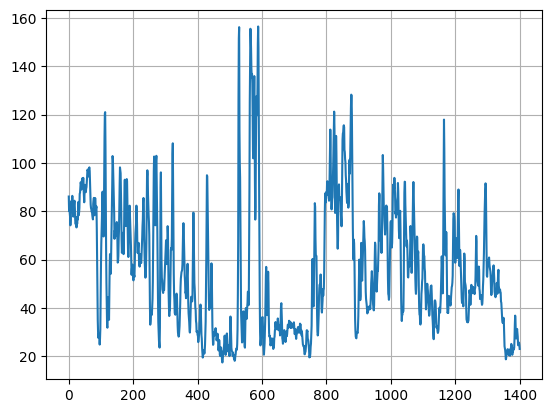

In [29]:
# Pandas line plots

log.gr.plot(grid=True);

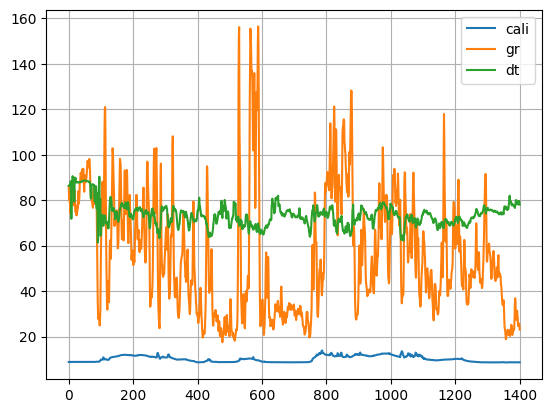

In [30]:
# Pandas line plots

log[['cali', 'gr','dt']].plot(grid=True);

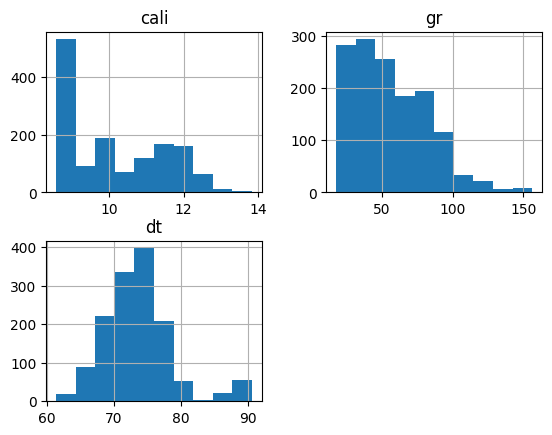

In [31]:
# Pandas histograms

log[['cali', 'gr','dt']].hist(grid=True);

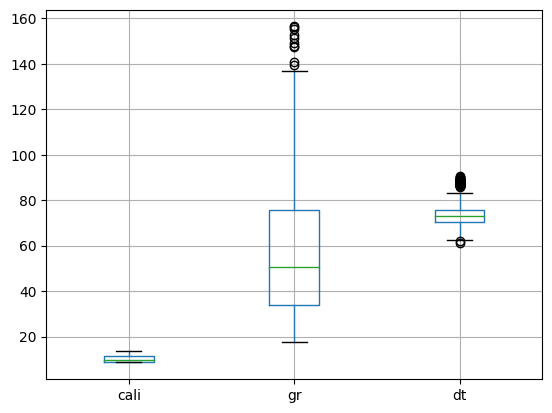

In [32]:
# Pandas boxplots

log[['cali', 'gr','dt']].boxplot(grid=True);

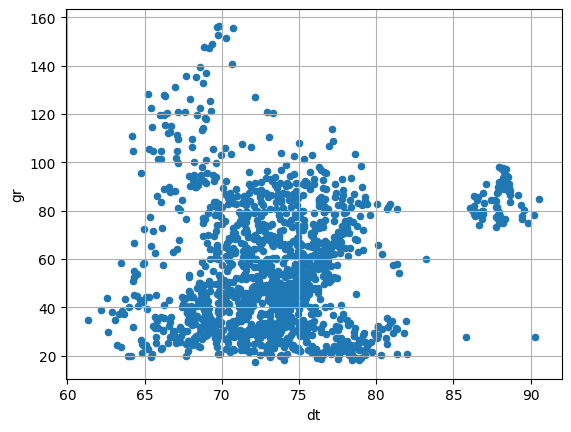

In [33]:
# Pandas boxplots

log.plot.scatter('dt', 'gr', grid=True);

<a  id="indis"></a>

<h2> 1.2 Input logs display</h2>

The simpler way to verify your input logs and cores is to plot them together in a multiplot. 

Instead of plotting directly in the notebook, we are going to use the *Matplotlib qt* library to send all our plots to independent and more flexible windows. For a better use of this library remember to declare the number of your plot in the arguments (num=1). 

(5250.0, 4550.0)

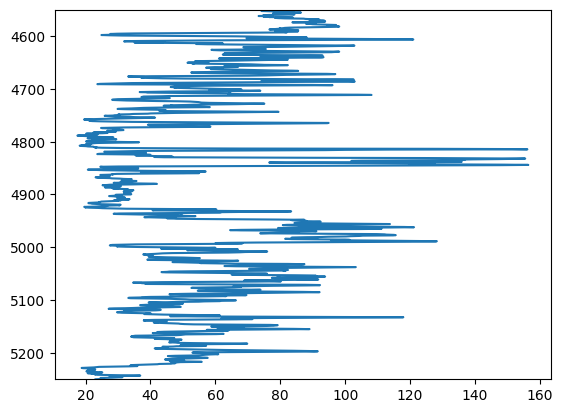

In [34]:
# Single plot of gamma-ray

plt.plot(gr, depth)
plt.ylim(5250, 4550)

In [35]:
# Activation of the Matplotlib qt UGI for the whole notebook

# %matplotlib qt
# %matplotlib inline

(5250.0, 4550.0)

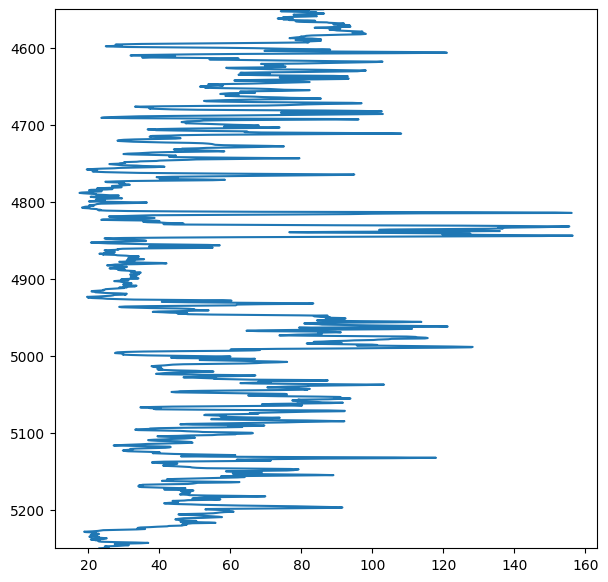

In [36]:
# Single and independent plot of gamma-ray

plt.figure(num=1, figsize=(7, 7))

plt.plot(gr, depth)
plt.ylim(5250, 4550)

In [37]:
# Before continue let's make our Jupyter cells a bit bigger

from IPython.display import display, HTML

display(HTML(data="""
<style>
    div#notebook-container    { width: 95%; }
    div#menubar-container     { width: 65%; }
    div#maintoolbar-container { width: 60%; }
</style>
"""))

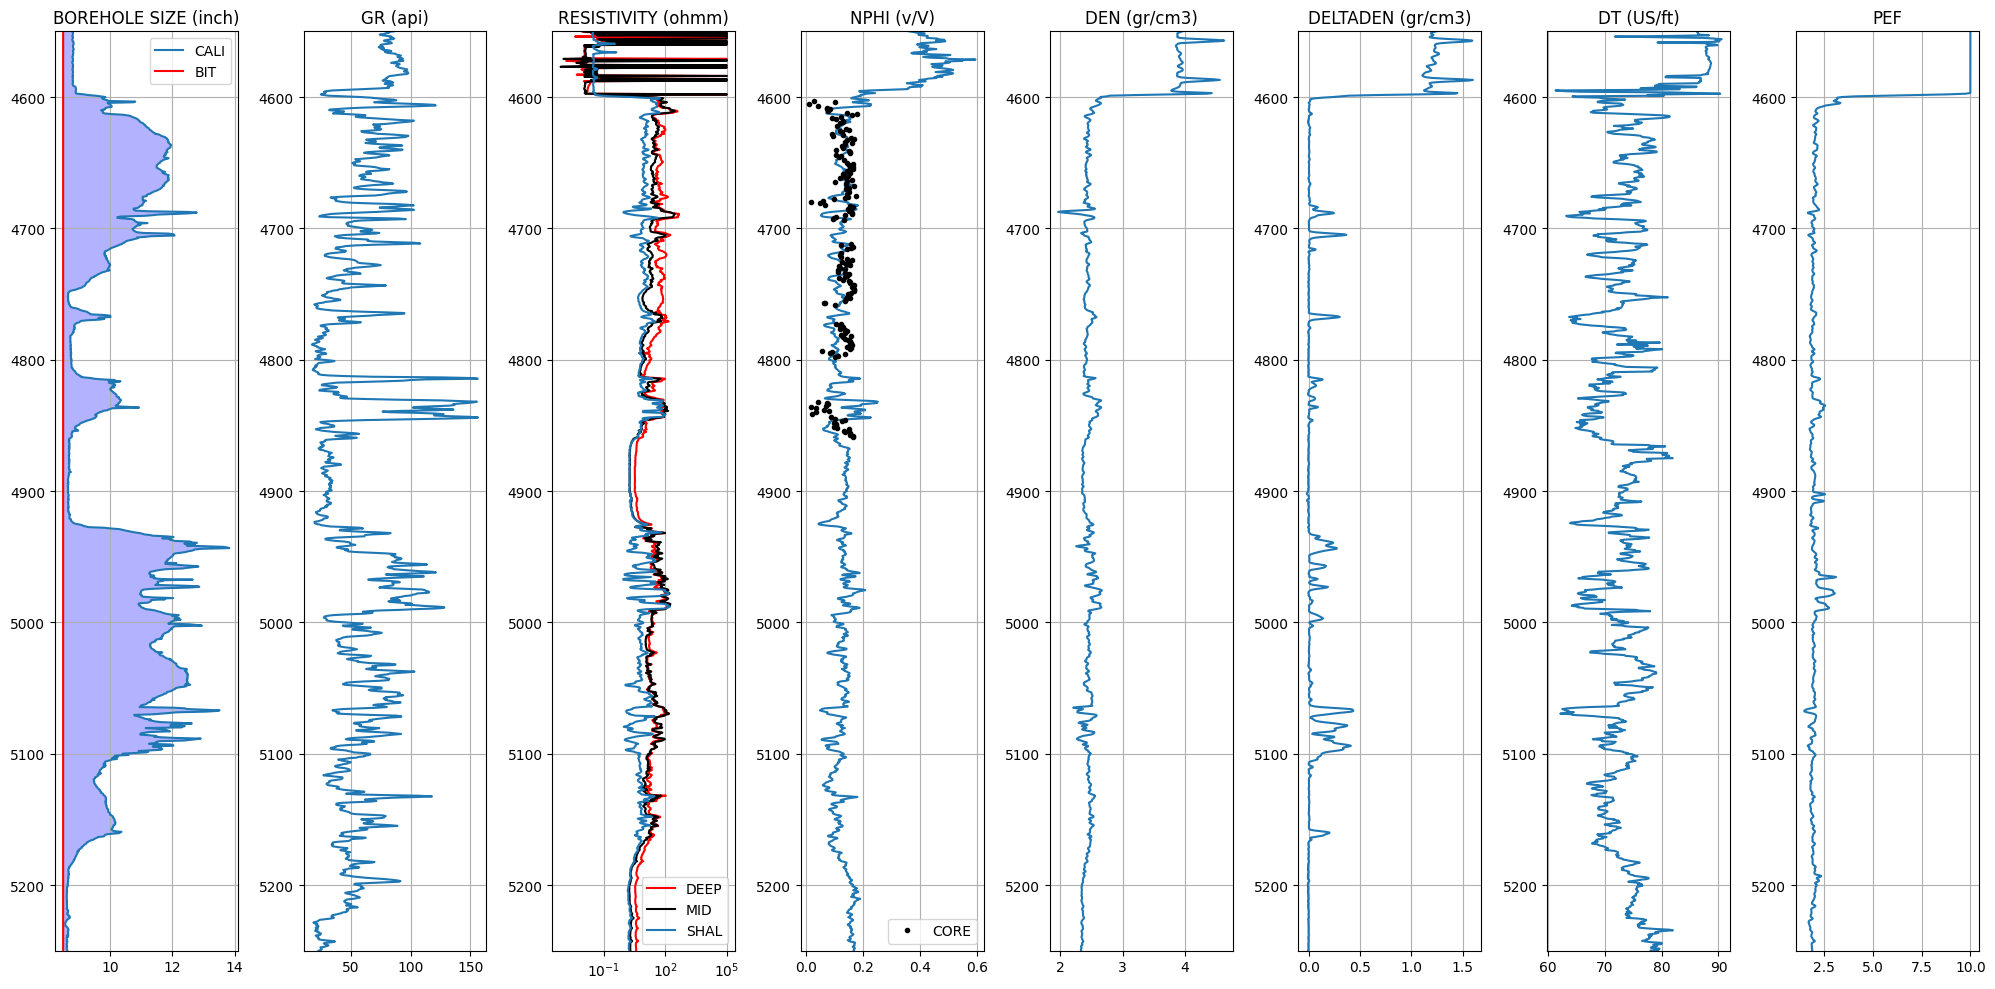

In [38]:
# First exploratory multiplot

plt.figure(2, figsize=(20, 10))

# Track 1
plt.subplot(1, 8, 1)
plt.plot(cali, depth, label='CALI')
plt.fill_betweenx(depth, cali, bs, where=bs >= cali,facecolor='brown', alpha=0.3)
plt.fill_betweenx(depth, cali, bs, where=bs <= cali, facecolor='blue', alpha=0.3)
plt.ylim(base, top)
plt.plot(bs, depth, 'r', label="BIT")
plt.title('BOREHOLE SIZE (inch)')
plt.legend()
plt.grid(True)

# Track 2
plt.subplot(1, 8, 2)
plt.plot(gr, depth)
plt.ylim(base, top)
plt.title('GR (api)')
plt.grid(True)

# Track 3
plt.subplot(1, 8, 3)
plt.semilogx(rdeep, depth, 'r', label="DEEP")
plt.semilogx(rmed, depth, 'k', label="MID")
plt.semilogx(rshal, depth, label="SHAL")
plt.ylim(base, top)
plt.title('RESISTIVITY (ohmm)')
plt.legend()
plt.grid(True)

# Track 4
plt.subplot(1, 8, 4)
plt.plot(nphi, depth)
plt.plot(log.core_phi, depth, '.', color='black', label = 'CORE')
plt.ylim(base, top)
plt.title('NPHI (v/V)')
plt.legend(loc='lower right')
plt.grid(True)

# Track 5
plt.subplot(1, 8, 5)
plt.plot(den, depth)
plt.ylim(base, top)
plt.title('DEN (gr/cm3)')
plt.grid(True)

# Track 6
plt.subplot(1, 8, 6)
plt.plot(dden, depth)
plt.ylim(base, top)
plt.title('DELTADEN (gr/cm3)')
plt.grid(True)

# Track 7
plt.subplot(1, 8, 7)
plt.plot(dt, depth)
plt.ylim(base, top)
plt.title('DT (US/ft)')
plt.grid(True)

# track 8
plt.subplot(1, 8, 8)
plt.plot(pef, depth)
plt.ylim(base, top)
plt.title('PEF')
plt.grid(True)

plt.tight_layout()
plt.show()

<a  id="inter"></a>

<h2> 1.3 Interval re selection</h2>

We have to eliminate the portion of the logs that were acquired inside the casing. For this, we use the **mask or filter tool** which has the following syntax:

`new_array = array[condition]`

The mask can be visualized (from Matt Eding) as follows, after setting a condition over a matrix, a new matrix is created with the items that met the condition:

<img src="NB_images/mask.gif" style="width: 600px;"/> 

In [39]:
# Re defining the log df by a mask or filter

log = log[log.depth >= 4600]
log

,depth,bs,cali,dden,den,dt,gr,nphi,pe,rdeep,rmed,rshal,core_depth,core_phi,core_k
100,4600.0,8.5,9.8540,0.2376,2.6451,64.9217,57.8059,0.1727,3.4288,8.9362,11.9212,2.1901,NaN,NaN,NaN
101,4600.5,8.5,9.7413,0.1322,2.6601,69.0075,66.7248,0.1624,3.1732,33.3499,45.5116,7.0827,NaN,NaN,NaN
102,4601.0,8.5,9.7976,0.0589,2.6379,69.5960,71.7880,0.1579,3.1438,54.2398,80.5891,55.2800,NaN,NaN,NaN
103,4601.5,8.5,9.7751,0.0201,2.6076,71.6236,77.2240,0.1797,3.1783,43.3331,58.4557,33.4518,NaN,NaN,NaN
104,4602.0,8.5,9.8540,0.0123,2.5937,73.5936,85.9182,0.2097,3.1505,37.2375,48.0052,20.3091,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1396,5248.0,8.5,8.6137,-0.0046,2.3448,78.1834,24.9118,0.1710,1.8610,3.7705,1.9423,1.6822,NaN,NaN,NaN
1397,5248.5,8.5,8.6137,-0.0057,2.3377,79.6487,25.6704,0.1702,1.8739,3.8424,1.9865,1.6716,NaN,NaN,NaN
1398,5249.0,8.5,8.6137,-0.0076,2.3354,79.2668,25.6939,0.1675,1.8906,3.8460,1.9887,1.7075,NaN,NaN,NaN
1399,5249.5,8.5,8.6287,-0.0087,2.3331,79.4633,24.7314,0.1682,1.8921,3.8620,2.0055,1.7721,NaN,NaN,NaN


In [40]:
# Re setting the index of the df

log = log.reset_index()
log = log.drop(['index'], axis=1)
log

,depth,bs,cali,dden,den,dt,gr,nphi,pe,rdeep,rmed,rshal,core_depth,core_phi,core_k
0,4600.0,8.5,9.8540,0.2376,2.6451,64.9217,57.8059,0.1727,3.4288,8.9362,11.9212,2.1901,NaN,NaN,NaN
1,4600.5,8.5,9.7413,0.1322,2.6601,69.0075,66.7248,0.1624,3.1732,33.3499,45.5116,7.0827,NaN,NaN,NaN
2,4601.0,8.5,9.7976,0.0589,2.6379,69.5960,71.7880,0.1579,3.1438,54.2398,80.5891,55.2800,NaN,NaN,NaN
3,4601.5,8.5,9.7751,0.0201,2.6076,71.6236,77.2240,0.1797,3.1783,43.3331,58.4557,33.4518,NaN,NaN,NaN
4,4602.0,8.5,9.8540,0.0123,2.5937,73.5936,85.9182,0.2097,3.1505,37.2375,48.0052,20.3091,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296,5248.0,8.5,8.6137,-0.0046,2.3448,78.1834,24.9118,0.1710,1.8610,3.7705,1.9423,1.6822,NaN,NaN,NaN
1297,5248.5,8.5,8.6137,-0.0057,2.3377,79.6487,25.6704,0.1702,1.8739,3.8424,1.9865,1.6716,NaN,NaN,NaN
1298,5249.0,8.5,8.6137,-0.0076,2.3354,79.2668,25.6939,0.1675,1.8906,3.8460,1.9887,1.7075,NaN,NaN,NaN
1299,5249.5,8.5,8.6287,-0.0087,2.3331,79.4633,24.7314,0.1682,1.8921,3.8620,2.0055,1.7721,NaN,NaN,NaN


In [41]:
# Now we have fewer points in the df

log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1301 entries, 0 to 1300
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   depth       1301 non-null   float64
 1   bs          1301 non-null   float64
 2   cali        1301 non-null   float64
 3   dden        1301 non-null   float64
 4   den         1301 non-null   float64
 5   dt          1301 non-null   float64
 6   gr          1301 non-null   float64
 7   nphi        1301 non-null   float64
 8   pe          1301 non-null   float64
 9   rdeep       1301 non-null   float64
 10  rmed        1301 non-null   float64
 11  rshal       1301 non-null   float64
 12  core_depth  182 non-null    float64
 13  core_phi    182 non-null    float64
 14  core_k      182 non-null    float64
dtypes: float64(15)
memory usage: 152.6 KB


In [42]:
# Again, let's make another alias for easy work, but now with the core data

depth = log.depth
bs = log.bs
cali = log.cali
dden = log.dden
den = log.den
dt = log.dt
gr = log.gr
nphi = log.nphi
pef = log.pe
rdeep = log.rdeep
rmed = log.rmed
rshal = log.rshal
core_phi = log.core_phi
core_k = log.core_k

In [43]:
# Again, the important information about the shorter logs

samples = len(depth)
interval = depth[samples - 1] - depth[0]
step = depth[2] - depth[1]
top = depth[0]
base = depth[samples - 1]

samples

1301

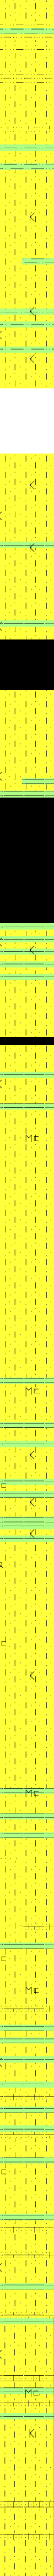

In [44]:
# Loading the mudlog image

mudlog = Image.open("Input/mudlog_4600_5250.png")
mudlog = mudlog.convert("RGB")
mudlog

In [45]:
# two-way-time to depth relationship

# log['tcum'] = 2 * (0.1524/ (1e6 * dt)).cumsum()

# plt.plot(log.tcum, depth)
# plt.ylim(base, top)
# plt.title('Velocity')
# plt.ylabel('Depth (ft)')

The top of display interval of the logs has changed from 4545 to 4600 ft, these limits are stored in top and base variables

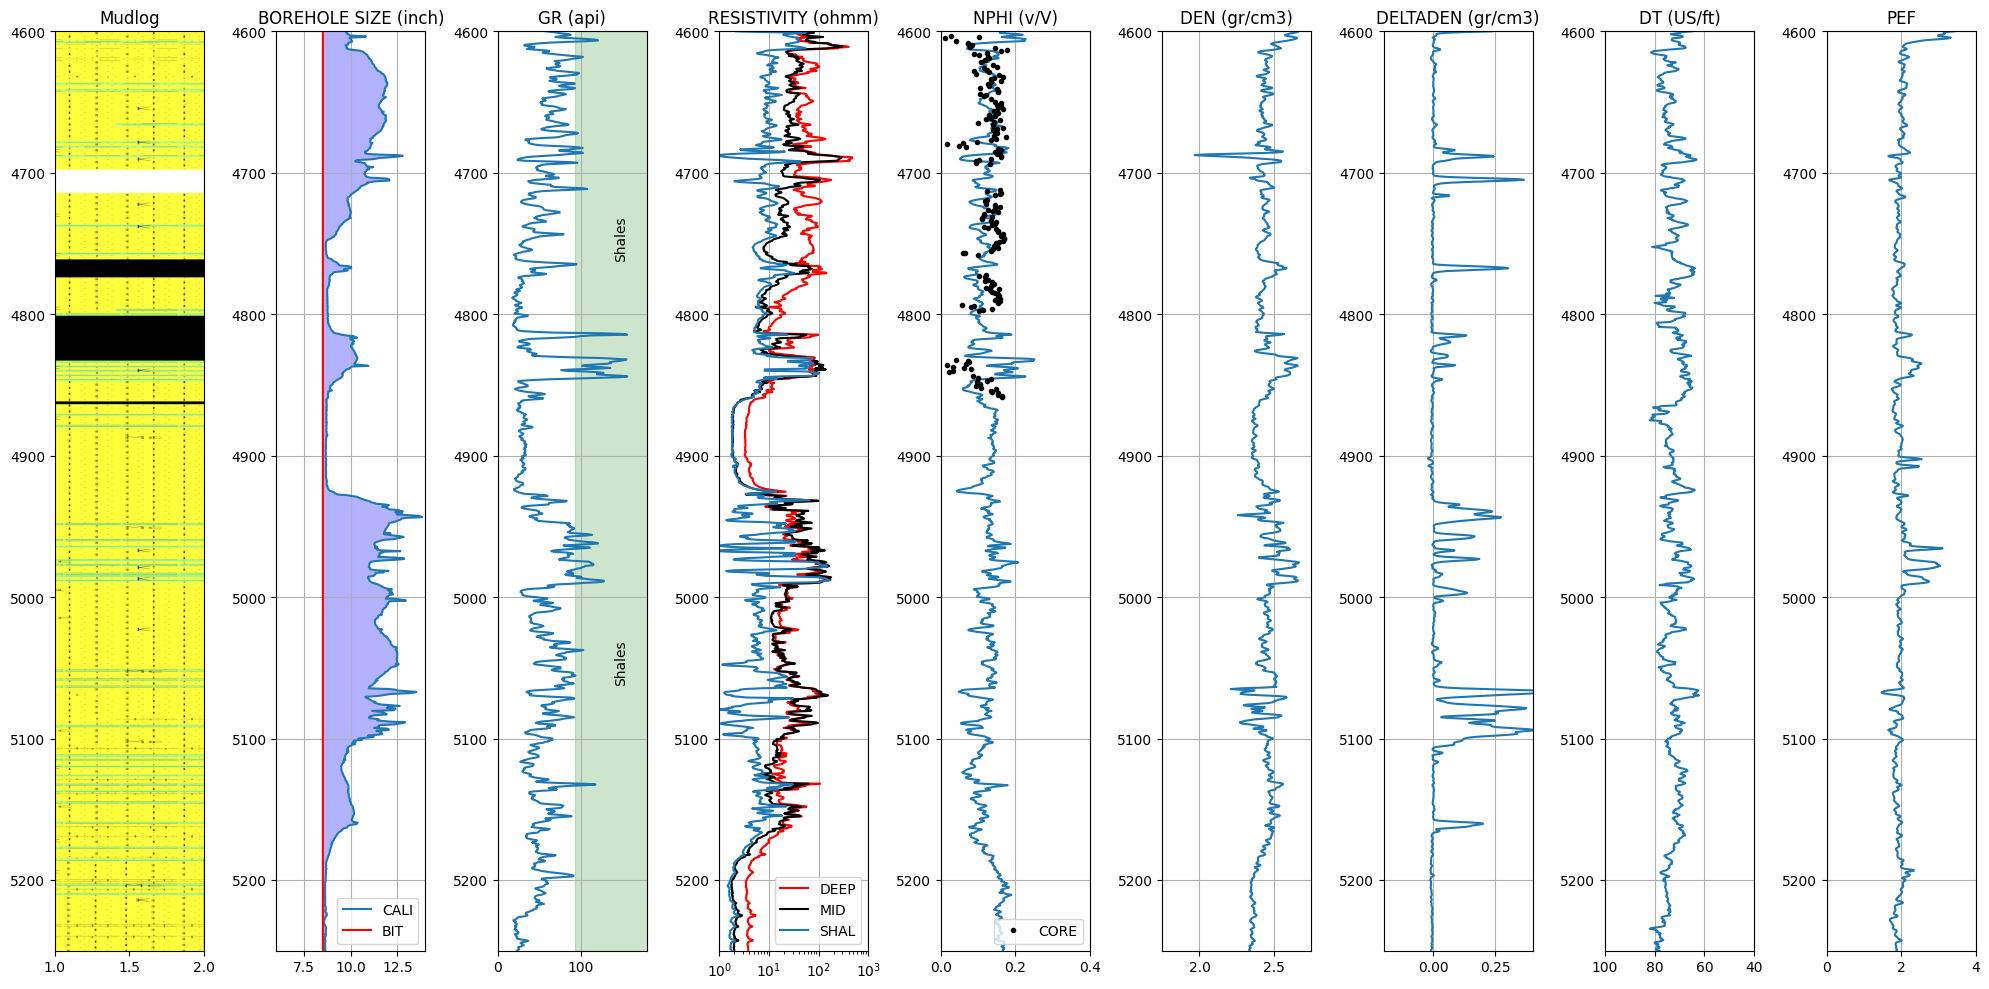

In [46]:
# Multiplot of the input logs without the casing interval

plt.figure(num=3, figsize=(20, 10))

# Track 1
plt.subplot(1, 9, 1)
plt.imshow(mudlog, aspect='auto', extent=(1, 2, base, top))
plt.title('Mudlog')

# Track 2
plt.subplot(1, 9, 2)
plt.plot(cali, depth, label='CALI')
plt.fill_betweenx(depth, cali, bs, where=bs >= cali,facecolor='brown', alpha=0.3)
plt.fill_betweenx(depth, cali, bs, where=bs <= cali, facecolor='blue', alpha=0.3)
plt.axis([6, 14, base, top])
plt.plot(bs, depth, 'r', label="BIT")
plt.title('BOREHOLE SIZE (inch)')
plt.legend()
plt.grid(True)

# Track 3
plt.subplot(1, 9, 3)
plt.plot(gr, depth)

# In this vertical interval of GR are my shales
plt.axvspan(93, 200, color='green', alpha=0.2)
plt.text(140, 4760, 'Shales', rotation=90)
plt.text(140, 5060, 'Shales', rotation=90)

plt.axis([0, 180, base, top])
plt.title('GR (api)')
plt.grid(True)

# Track 4
plt.subplot(1, 9, 4)
plt.semilogx(rdeep, depth, 'r', label="DEEP")
plt.semilogx(rmed, depth, 'k', label="MID")
plt.semilogx(rshal, depth, label="SHAL")
plt.axis([1, 1000, base, top])
plt.title('RESISTIVITY (ohmm)')
plt.legend()
plt.grid(True)

# Track 5
plt.subplot(1, 9, 5)
plt.plot(nphi, depth)
plt.plot(core_phi, depth, '.', color='black', label = 'CORE')
plt.axis([0, 0.4, base, top])
plt.title('NPHI (v/V)')
plt.legend(loc='lower right')
plt.grid(True)

# Track 6
plt.subplot(1, 9, 6)
plt.plot(den, depth)
plt.ylim(base, top)
plt.axis([1.75, 2.75, base, top])
plt.title('DEN (gr/cm3)')
plt.grid(True)

# Track 7
plt.subplot(1, 9, 7)
plt.plot(dden, depth)
plt.axis([-0.2, 0.4, base, top])
plt.title('DELTADEN (gr/cm3)')
plt.grid(True)

# Track 8
plt.subplot(1, 9, 8)
plt.plot(dt, depth)
# plt.plot(log.tcum, depth)
plt.axis([100, 40, base, top])
plt.title('DT (US/ft)')
plt.grid(True)

# track 9
plt.subplot(1, 9, 9)
plt.plot(pef, depth)
plt.axis([0, 4, base, top])
plt.title('PEF')
plt.grid(True)

plt.tight_layout()
plt.show()

<a  id="inhist"></a>

<h2> 1.4 Input logs histograms </h2>

In addition to the Pandas histograms, Matplotlib histograms should be the next step to understanding your input logs. As well as the logs, they can be combined in a multiplot:

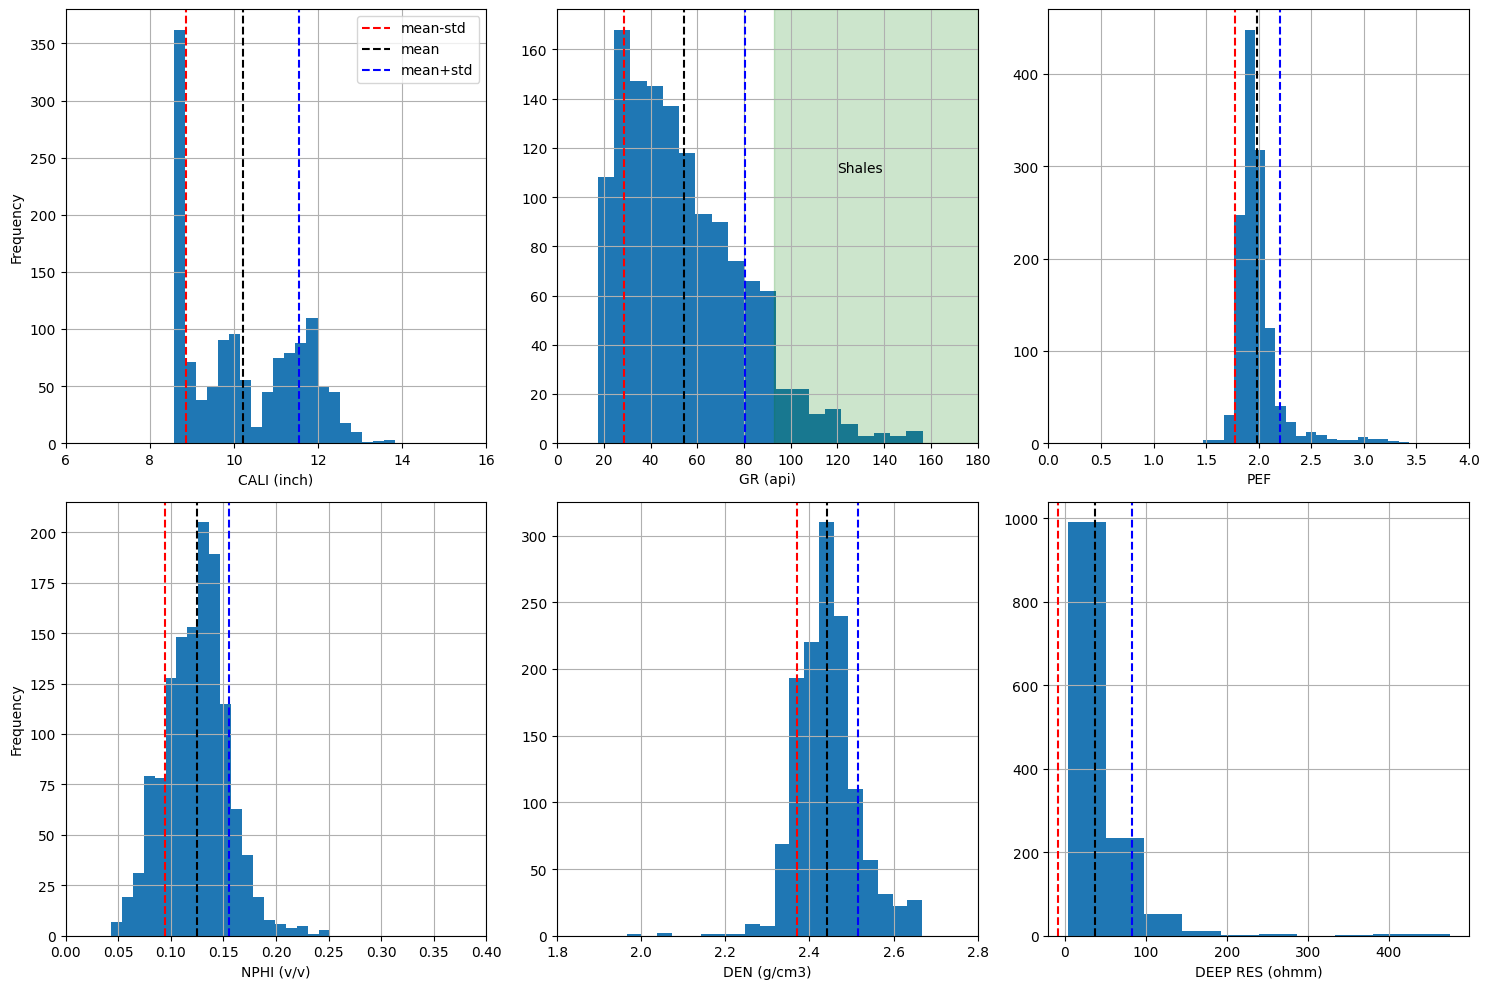

In [47]:
plt.figure(num=4, figsize=(15, 10))

plt.subplot(2,3,1)
plt.hist(cali, bins=20)
plt.axvline(x=np.mean(cali)-np.std(cali), ls = "--", color='red',label='mean-std')
plt.axvline(x=np.mean(cali), ls = "--", color='black',label='mean')
plt.axvline(x=np.mean(cali)+np.std(cali), ls = "--", color='blue',label='mean+std')
plt.xlim(6, 16)
plt.xlabel('CALI (inch)')
plt.ylabel('Frequency')
plt.grid(True)
plt.legend()

plt.subplot(2,3,2)
plt.hist(gr, bins=20)
plt.axvline(x=np.mean(gr)-np.std(gr), ls = "--", color='red')
plt.axvline(x=np.mean(gr), ls = "--", color='black')
plt.axvline(x=np.mean(gr)+np.std(gr), ls = "--", color='blue')

# In this vertical interval of GR are my shales
plt.axvspan(93, 180, color='green', alpha=0.2)
plt.text(120, 110, 'Shales')

plt.xlim(0, 180)
plt.xlabel('GR (api)')
plt.grid(True)

plt.subplot(2,3,3)
plt.hist(pef, bins=20)
plt.axvline(x=np.mean(pef)-np.std(pef), ls = "--", color='red')
plt.axvline(x=np.mean(pef), ls = "--", color='black')
plt.axvline(x=np.mean(pef)+np.std(pef), ls = "--", color='blue')
plt.xlim(0, 4)
plt.xlabel ('PEF')
plt.grid(True)

plt.subplot(2,3,4)
plt.hist(nphi, bins=20)
plt.axvline(x=np.mean(nphi)-np.std(nphi), ls = "--", color='red')
plt.axvline(x=np.mean(nphi), ls = "--", color='black')
plt.axvline(x=np.mean(nphi)+np.std(nphi), ls = "--", color='blue')
plt.xlim(0, 0.4)
plt.xlabel ('NPHI (v/v)')
plt.ylabel('Frequency')
plt.grid(True)

plt.subplot(2,3,5)
plt.hist(den, bins=20)
plt.axvline(x=np.mean(den)-np.std(den), ls = "--", color='red')
plt.axvline(x=np.mean(den), ls = "--", color='black')
plt.axvline(x=np.mean(den)+np.std(den), ls = "--", color='blue')
plt.xlim(1.8, 2.8)
plt.xlabel ('DEN (g/cm3)')
plt.grid(True)

plt.subplot(2,3,6)
plt.hist(rdeep)
plt.axvline(x=np.mean(rdeep)-np.std(rdeep), ls = "--", color='red')
plt.axvline(x=np.mean(rdeep), ls = "--", color='black')
plt.axvline(x=np.mean(rdeep)+np.std(rdeep), ls = "--", color='blue')
# plt.xscale('log')
plt.xlabel ('DEEP RES (ohmm)')
plt.grid(True)

plt.tight_layout()
plt.show()

<a  id="incross"></a>

<h2> 1.5 Input logs cross plots </h2>

Cross plots provide an extra and detail view of your input logs. They help to the identification of the lithology, finding anomalies, and in the selection of parameters needed in the calculations of output logs.

Some of the shown cross plot have reference layouts (lines) that are just extra plots over the cross plots. These layout, saved in the folder of the same name, were acquired (as x and y pairs) from classic plot using the following digitalization tool:

https://automeris.io/WebPlotDigitizer/

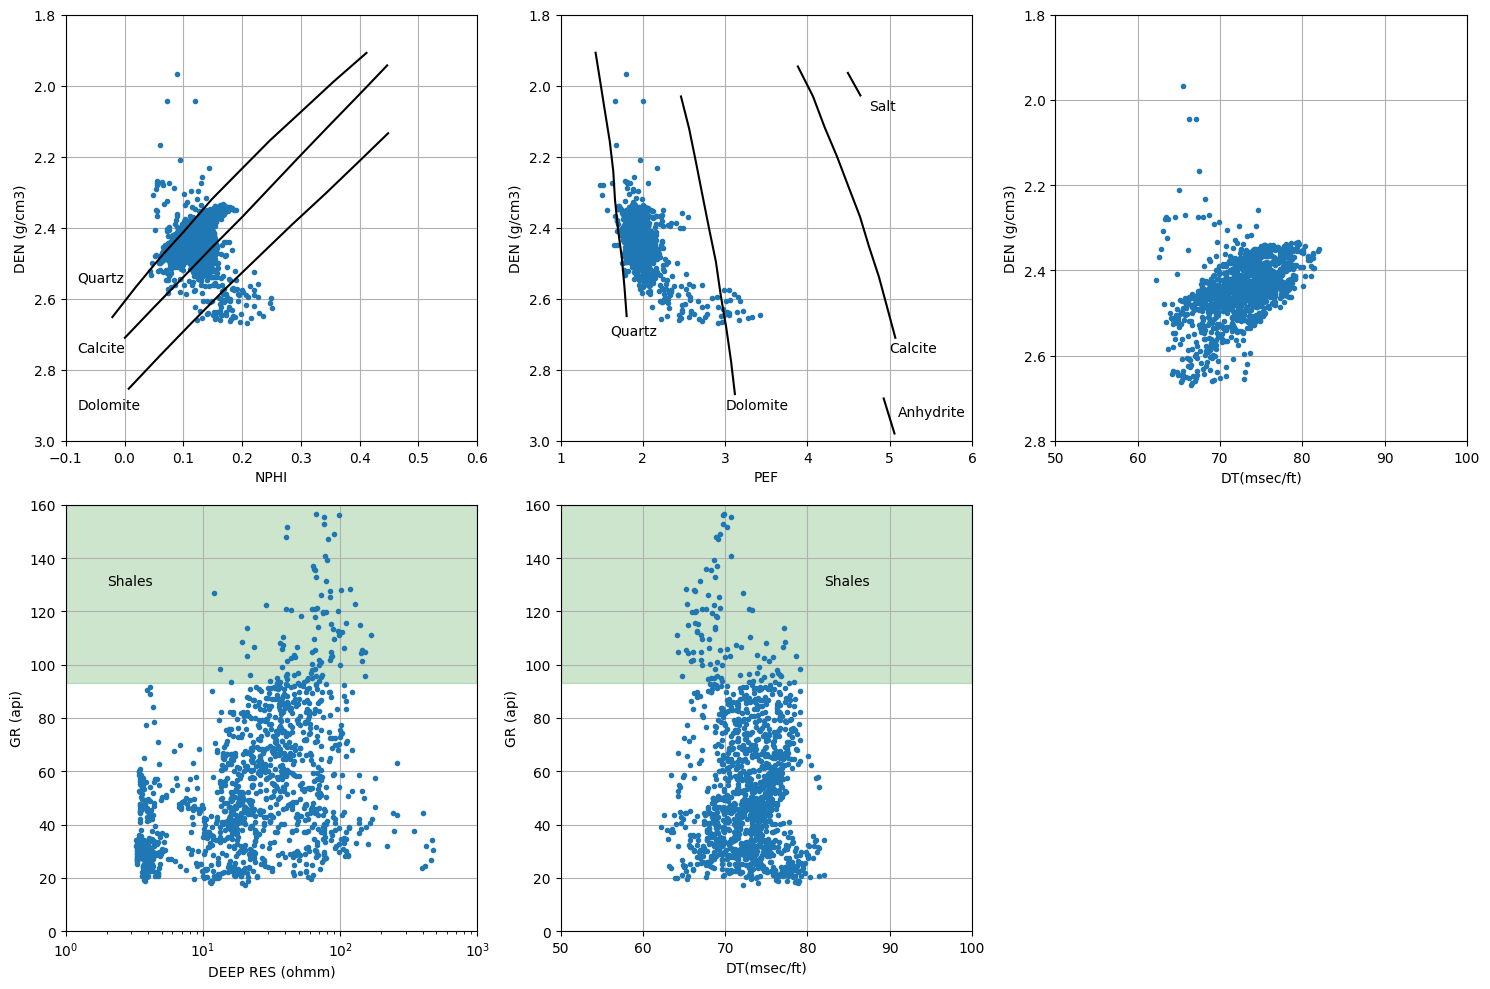

In [48]:
# Input logs cross plots

# neu vs. den xpolt

plt.figure(num=5, figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.plot(nphi, den, '.')
plt.ylim(3, 1.8)
plt.xlim(-0.1, 0.6)
plt.xlabel('NPHI')
plt.ylabel('DEN (g/cm3)')
plt.grid(True)

# loading the layout

neu2den_qz = np.genfromtxt('Layouts/neu2den_qz.csv',delimiter=',', dtype=np.float32)
neu2den_cal = np.genfromtxt('Layouts/neu2den_cal.csv', delimiter=',', dtype=np.float32)
neu2den_dol = np.genfromtxt('Layouts/neu2den_dol.csv', delimiter=',', dtype=np.float32)

# Ploting the layout and its labels

plt.plot(neu2den_qz[:, 0], neu2den_qz[:, 1], 'black')
plt.text(-0.08, 2.55, 'Quartz')
plt.plot(neu2den_cal[:, 0], neu2den_cal[:, 1], 'black')
plt.text(-0.08, 2.75, 'Calcite')
plt.plot(neu2den_dol[:, 0], neu2den_dol[:, 1], 'black')
plt.text(-0.08, 2.91, 'Dolomite')

# pef vs. den xpolt

plt.subplot(2, 3, 2)
plt.plot(pef, den, '.')
plt.ylim(3, 1.8)
plt.xlim(1, 6)
plt.xlabel('PEF')
plt.ylabel('DEN (g/cm3)')
plt.grid(True)

# loading the layout

pef2den_qz = np.genfromtxt('layouts/pef2den_qz.csv', delimiter=',', dtype=np.float32)
pef2den_cal = np.genfromtxt('layouts/pef2den_cal.csv', delimiter=',', dtype=np.float32)
pef2den_dol = np.genfromtxt('layouts/pef2den_dol.csv', delimiter=',', dtype=np.float32)
pef2den_sal = np.genfromtxt('layouts/pef2den_sal.csv', delimiter=',', dtype=np.float32)
pef2den_anh = np.genfromtxt('layouts/pef2den_anh.csv', delimiter=',', dtype=np.float32)

# Ploting the layout and its labels

plt.plot(pef2den_qz[:, 0], pef2den_qz[:, 1], 'black')
plt.text(1.6, 2.7, 'Quartz')
plt.plot(pef2den_cal[:, 0], pef2den_cal[:, 1], 'black')
plt.text(5, 2.75, 'Calcite')
plt.plot(pef2den_dol[:, 0], pef2den_dol[:, 1], 'black')
plt.text(3, 2.91, 'Dolomite')
plt.plot(pef2den_sal[:, 0], pef2den_sal[:, 1], 'black')
plt.text(4.75, 2.07, 'Salt')
plt.plot(pef2den_anh[:, 0], pef2den_anh[:, 1], 'black')
plt.text(5.1, 2.93, 'Anhydrite')

# %% Other plots

plt.subplot(2, 3, 3)
plt.plot(dt, den, '.')
plt.ylim(2.8, 1.8)
plt.xlim(50, 100)
plt.xlabel('DT(msec/ft)')
plt.ylabel('DEN (g/cm3)')
plt.grid(True)

plt.subplot(2, 3, 4)
plt.semilogx(rdeep, gr, '.')

# In this horizontal interval of GR are my shales
plt.axhspan(93, 160, color='green', alpha=0.2)
plt.text(2, 130, 'Shales')

plt.xlim(1, 1000)
plt.ylim(0, 160)
plt.xlabel('DEEP RES (ohmm)')
plt.ylabel('GR (api)')
plt.grid(True)

plt.subplot(2, 3, 5)
plt.plot(dt, gr, '.')
plt.axhspan(93, 160, color='green', alpha=0.2)
plt.text(82, 130, 'Shales')
plt.xlim(50, 100)
plt.ylim(0, 160)
plt.xlabel('DT(msec/ft)')
plt.ylabel('GR (api)')
plt.grid(True)

plt.tight_layout()
plt.show()

[Return to Table of Content](#toc)

<a  id="par"></a>

<h1> 2 Parameter selection </h1>

By printing the main statistical parameters and histograms of the logs and masked or filtered logs, you can answer questions such as:

                     What is the resistivity of the shales?
                     What is the sonic of the sands?
                     ...
                     
In order to answer the first question we can use the fact that shales have high values of Gamma Ray values (GR). The following GUDFs help us in the selection of parameters:

* Basic statistical parameters of a log; `basic_stat()`
* Plotting a histogram with basic statistical parameters of a log; `histo_par()`
* Reporting and plotting histograms with basic statistical parameters of a log and mask or filter log; `log_mlog()`

Let's see and execute them:

In [49]:
# Main statistical parameters of Deep Resistivity

log_udf.basic_stat(rdeep)

samples     = 1301
range       = 472.1796
min         = 3.2588
p33         = 15.5849
mean        = 36.7552099923136
p66         = 37.7685
max         = 475.4384
std         = 45.485871155924016
mean + 3std = 173.21282346008564


In [50]:
# Main statistical parameters of filtered deep resistivity in the shales

deep_res_shale = rdeep[gr > 93]

log_udf.basic_stat(deep_res_shale)

samples     = 100
range       = 157.4081
min         = 11.9712
p33         = 50.833347
mean        = 68.929127
p66         = 76.002904
max         = 169.3793
std         = 32.901081441353426
mean + 3std = 167.63237132406027


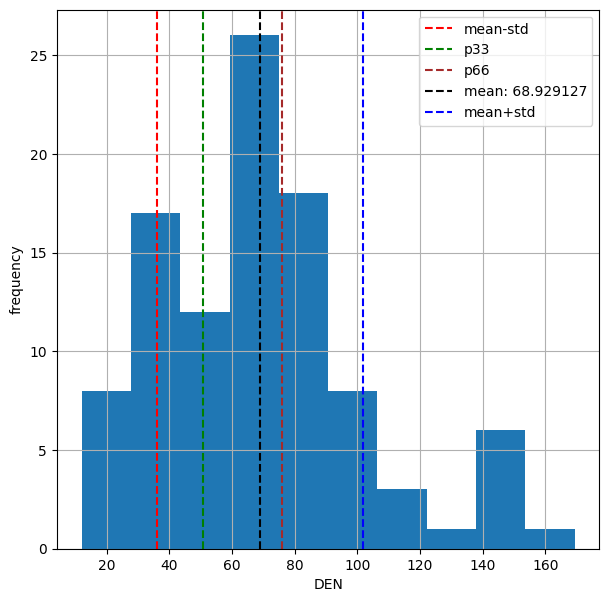

In [51]:
# Histogram of the filtered rdeep

plt.close('6')

plt.figure(num=6, figsize=(7, 7))

log_udf.histo_par(rdeep[gr > 93], 'DEN')

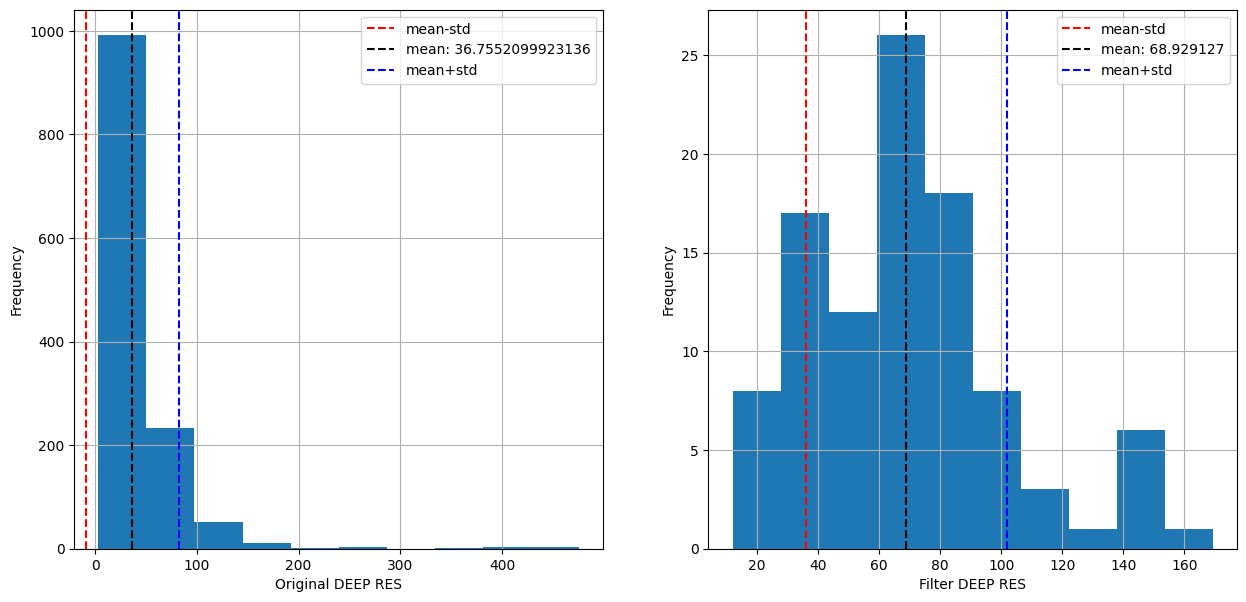

In [52]:
# Report and histogram of regular and filtered rdeep or resistivity in the shales

plt.close('6')

plt.figure(num=6, figsize=(15, 7))

log_udf.log_mlog(rdeep, 'DEEP RES', rdeep[gr > 93])

[Return to Table of Content](#toc)

<a  id="output"></a>

<h1>3 Output logs</h1>

By output logs, we understand the logs that are calculated from the original logs (input), those acquired in the well. The main three output logs or curves that we are going to compute, and their required input logs, are: 

* **Volume of shale (VSH)**: requires gamma ray (GR)  or spontaneous potential (SP)
* **Porosity (PHI)**: requires neutron porosity (NPHI), density (DEN), sonic (DT)
* **Water saturation (SW)**: deep resistivity (RDEEP)

<a  id="cal"></a>

<h2>3.1 Output logs calculation</h2>

There are several equations or models (some very complex) for each of the three output logs. For this demonstration, we are going to use the simplest possible, which can be seen in the following cell

<a  id="vsh"></a>

<h3>3.1.1 Volume of shale</h3>

In [53]:
log_udf.basic_stat(gr)

samples     = 1301
range       = 138.9766
min         = 17.4693
p33         = 38.6175
mean        = 54.482075941583396
p66         = 61.6003
max         = 156.4459
std         = 25.902254533504912
mean + 3std = 132.18883954209812


In [54]:
# Volume of shale by gamma ray

gr_cl = 17    # gr clean or minimum
gr_sh = 157    # gr of shales or maximum

# We can save the outputs to independent arrays, create a new df, or add them to the df of logs, let´s do the last option:

log['vsh'] = (gr - gr_cl)/(gr_sh - gr_cl)    # Similar to the unity-base normalization  

log.vsh = np.maximum(np.minimum(log.vsh, 1), 0.0001)   # Restreing the result  between (0,1]

In [55]:
log.vsh

0       0.291471
1       0.355177
2       0.391343
3       0.430171
4       0.492273
          ...   
1296    0.056513
1297    0.061931
1298    0.062099
1299    0.055224
1300    0.043314
Name: vsh, Length: 1301, dtype: float64

<div class="alert alert-block alert-warning"> <font size="6"> &#9757;&#127997;</font> <b> Question.</b> What type of operation is this? Are we looping along the entire serie?
</div>

<a  id="phi"></a>

<h3>3.1.2 Porosity</h3>

In [56]:
# Total sonic porosity

dt_qz = 56    # sonic of quartz
dt_f = 190    # sonic of water (mud filtrate)

log['sphi'] = (dt - dt_qz)/(dt_f - dt_qz)

log.sphi = np.maximum(np.minimum(log.sphi, 1), 0.0001)

To compute the effective porosity you have to subtract the porosity of the shale from the total porosity. To find the porosity of the shale you can use a GUDF as the one used above:

In [57]:
# Total sonic porosity of the shale

log_udf.basic_stat(log.sphi)

samples     = 1301
range       = 0.14770746268656718
min         = 0.046242537313432835
p33         = 0.11384253731343288
mean        = 0.12439902715477189
p66         = 0.13751940298507462
max         = 0.19395
std         = 0.027353327600174334
mean + 3std = 0.20645900995529487


In [58]:
# Sonic of the shales

log_udf.basic_stat(log.sphi[gr > 93])

samples     = 100
range       = 0.11074104477611946
min         = 0.061240298507462654
p33         = 0.09058681343283585
mean        = 0.10601557462686567
p66         = 0.10964313432835825
max         = 0.1719813432835821
std         = 0.028293498386823657
mean + 3std = 0.19089606978733664


In [59]:
# Effective sonic porosity

sphi_sh = 0.106

log['esphi'] = log.sphi - sphi_sh*log.vsh

log.esphi = np.maximum(np.minimum(log.esphi, 1), 0.0001)

In [60]:
# Total Neutron-density porosity

d_m = 2.65    # density of quartz
d_f = 1       # density of water (mud filtrate)

log['dphi'] = (d_m - den)/(d_m - d_f)

log['ndphi'] = (nphi + log.dphi)/2    # NPHI has to be in quartz matrix, NPHI_sand = NPHI_lime + 0.04

log.ndphi = np.maximum(np.minimum(log.ndphi, 1), 0.0001)

In [61]:
# Total neutron-density porosity of the shale

log_udf.basic_stat(log.ndphi)

samples     = 1301
range       = 0.19473030303030303
min         = 0.05666818181818179
p33         = 0.11280000000000001
mean        = 0.1254658374676822
p66         = 0.13448484848484854
max         = 0.2513984848484848
std         = 0.025581781547020475
mean + 3std = 0.20221118210874361


In [62]:
# Neutron-density porosity of the shales

log_udf.basic_stat(log.ndphi[gr > 93])

samples     = 100
range       = 0.09353181818181816
min         = 0.05904242424242421
p33         = 0.10290483333333335
mean        = 0.1125007727272727
p66         = 0.12372257575757577
max         = 0.15257424242424236
std         = 0.021375580411942714
mean + 3std = 0.17662751396310084


In [63]:
# Effective neutron-density porosity

ndphi_sh = 0.113

log['endphi'] = log.ndphi - ndphi_sh*log.vsh

log.endphi = np.maximum(np.minimum(log.endphi, 1), 0.0001)

<a  id="bad"></a>

<h3>3.1.3 Badhole and composite porosity</h3>

To improve the estimation of porosity in the badhole intervals we use the sonic porosity instead of the neutron-density porosity:

In [64]:
bs

0       8.5
1       8.5
2       8.5
3       8.5
4       8.5
       ... 
1296    8.5
1297    8.5
1298    8.5
1299    8.5
1300    8.5
Name: bs, Length: 1301, dtype: float64

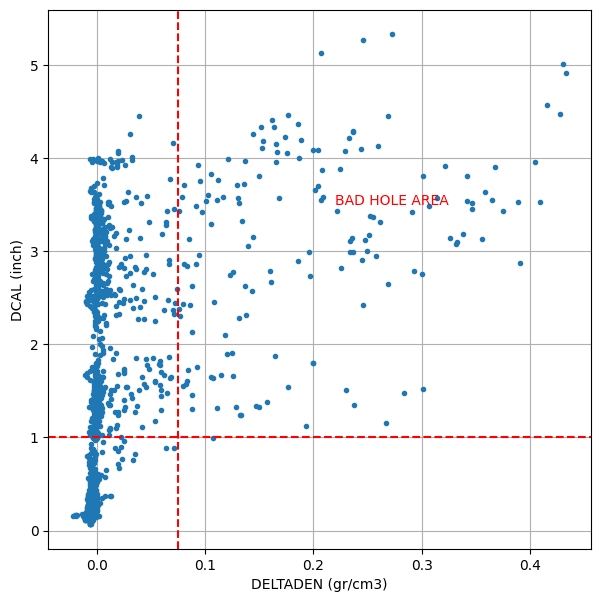

In [65]:
# Let's define, with the differencial caliper and the delta density, the cutoff for bad hole

log['dcal'] = cali - bs

plt.figure(num=7, figsize=(7, 7))

plt.plot(dden, log.dcal, '.')
plt.ylabel('DCAL (inch)')
plt.xlabel('DELTADEN (gr/cm3)')
plt.axhline(y=1, ls="--", color='red')
plt.axvline(x=0.075, ls="--", color='red')
plt.text(0.22, 3.5, 'BAD HOLE AREA', color='red')
plt.grid(True)
plt.show()

In [66]:
# Composite (made of several) porosity addresses the bad hole intervals

log["badhole"] = np.where(((log.dcal > 1) & (log.dden > 0.075 )), 1, 0)

log["comp_phi"] = np.where(((log.dcal > 1) & (log.dden > 0.075 )), log.sphi, log.ndphi)

log["comp_ephi"] = np.where(((log.dcal > 1) & (log.dden > 0.075 )), log.esphi, log.endphi)

In [67]:
# The previous done with loop and arrays (3 vs. 12 lines of code)

# badhole = np.zeros(samples)
# comp_phi = np.zeros(samples)
# comp_eff_phi = np.zeros(samples)

# for i in range(0, samples):
#     if (dcal[i] > 1 and dden[i] > 0.075):
#         badhole[i] = 1
#         comp_phi[i] = sphi[i]
#         comp_eff_phi[i] = eff_sphi[i]
        
#     else:
#         badhole[i] = 0
#         comp_phi[i] = ndphi[i]
#         comp_eff_phi[i] = eff_ndphi[i]

The efficiency of **vectorized operations** is not limited to the number of lines of code, vectorized operations can be hundreds of times faster than the same operation done with loops.

Check this article: https://www.kaggle.com/code/yushg123/for-loops-vs-vectorized-who-wins-and-by-how-much/notebook

In [68]:
# The last two are the results

log[['badhole', 'sphi', 'ndphi', 'esphi', 'endphi', 'comp_phi', 'comp_ephi']]

,badhole,sphi,ndphi,esphi,endphi,comp_phi,comp_ephi
0,1,0.066580,0.087835,0.035684,0.054899,0.066580,0.035684
1,1,0.097071,0.078139,0.059422,0.038004,0.097071,0.059422
2,0,0.101463,0.082617,0.059980,0.038395,0.082617,0.038395
3,0,0.116594,0.102698,0.070996,0.054089,0.102698,0.054089
4,0,0.131296,0.121911,0.079115,0.066284,0.121911,0.066284
...,...,...,...,...,...,...,...
1296,0,0.165548,0.177985,0.159557,0.171599,0.177985,0.171599
1297,0,0.176483,0.179736,0.169918,0.172738,0.179736,0.172738
1298,0,0.173633,0.179083,0.167050,0.172066,0.179083,0.172066
1299,0,0.175099,0.180130,0.169245,0.173890,0.180130,0.173890


In [69]:
log.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
depth,1301.0,4925.000000,187.855330,4600.000000,4762.500000,4925.000000,5087.500000,5250.000000
bs,1301.0,8.500000,0.000000,8.500000,8.500000,8.500000,8.500000,8.500000
cali,1301.0,10.208265,1.336851,8.568600,8.760300,9.981800,11.462700,13.830600
dden,1301.0,0.026218,0.072349,-0.022000,-0.004600,-0.000200,0.009900,0.432900
den,1301.0,2.441987,0.072648,1.967400,2.393400,2.439100,2.476900,2.667800
dt,1301.0,72.669470,3.666755,62.196500,70.169600,72.969400,75.311800,81.989300
gr,1301.0,54.482076,25.912215,17.469300,33.186300,48.694300,69.975000,156.445900
nphi,1301.0,0.124863,0.030370,0.042800,0.104500,0.126700,0.143300,0.251500
pe,1301.0,1.985233,0.214989,1.473300,1.874300,1.939000,2.032300,3.428800
rdeep,1301.0,36.755210,45.503362,3.258800,10.928000,23.418300,48.857900,475.438400


<a  id="vs"></a>

### 3.1.4 Total vs. effective porosity

Is core phi closer to total or effective log porosity? Let's review the correlations between them, by correlation coefficient and graphically:

In [70]:
log[['comp_phi', 'core_phi']].corr()

,comp_phi,core_phi
comp_phi,1.000000,0.129726
core_phi,0.129726,1.000000


In [71]:
log[['comp_ephi', 'core_phi']].corr()

,comp_ephi,core_phi
comp_ephi,1.000000,0.373915
core_phi,0.373915,1.000000


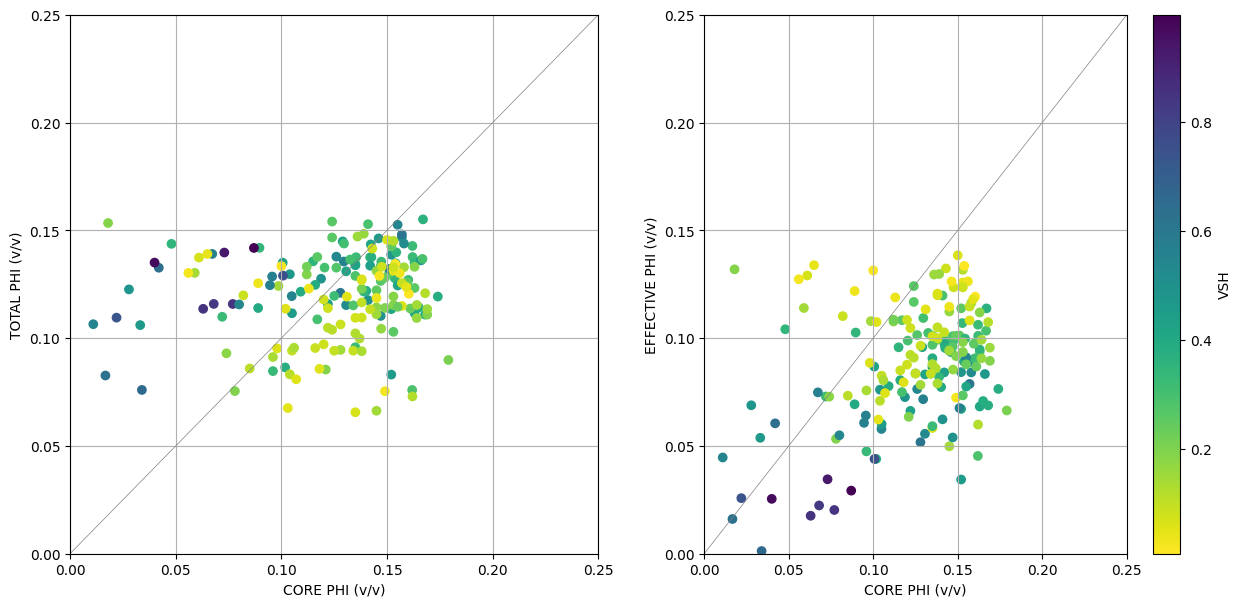

In [72]:
# Is core phi closer to total or effective log porosity?

# %matplotlib inline

plt.figure(num=8, figsize=(15, 7))

x45 = [0, 1]
y45 = x45

plt.subplot(1, 2, 1)
plt.scatter(core_phi, log.comp_phi, c=log.vsh, cmap='viridis_r')
plt.plot(x45, y45, 'gray', linewidth=0.5)
plt.axis([0, 0.25, 0, 0.25])
plt.xlabel('CORE PHI (v/v)')
plt.ylabel('TOTAL PHI (v/v)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(core_phi, log.comp_ephi, c=log.vsh, cmap='viridis_r')
plt.plot(x45, y45, 'gray', linewidth=0.5)
plt.axis([0, 0.25, 0, 0.25])
plt.xlabel('CORE PHI (v/v)')
plt.ylabel('EFFECTIVE PHI (v/v)')
plt.grid(True)

# Color scale bar

cb = plt.colorbar()
cb.set_label('VSH')

plt.show()

Here there is information on the colormaps:

https://matplotlib.org/3.1.0/gallery/color/named_colors.html

https://matplotlib.org/tutorials/colors/colormaps.html

<a  id="sw"></a>

<h3>3.1.5 Water saturarion by Archie</h3>

<b>The Archie´s equation</b> is most the important equation in the log analysis because it gave the first way to access the amount of oil present in a subsurface rocks (clean sandstones) :

<img src="NB_images\archie.png" style="width:600px">

Before computing the saturation we have to have a value for the resistivity of the formation water (Rw). If you don't have a sample you have to look for a water bearing interval and do the estimation of the Rw there:

In [73]:
depth

0       4600.0
1       4600.5
2       4601.0
3       4601.5
4       4602.0
         ...  
1296    5248.0
1297    5248.5
1298    5249.0
1299    5249.5
1300    5250.0
Name: depth, Length: 1301, dtype: float64

In [74]:
# Temperature along the well

mrt = 104    # Cº
mrtd = 5250   # ft

geo_grad = (mrt - 25)/mrtd
log['temp'] = geo_grad*depth + 25
log.temp

0        94.219048
1        94.226571
2        94.234095
3        94.241619
4        94.249143
           ...    
1296    103.969905
1297    103.977429
1298    103.984952
1299    103.992476
1300    104.000000
Name: temp, Length: 1301, dtype: float64

ro = 600    3.3242
Name: rdeep, dtype: float64
phi = 600    0.147735
Name: comp_ephi, dtype: float64
temp = 600    98.733333
Name: temp, dtype: float64
600 is the index at depth of 4900 feet (fix) 



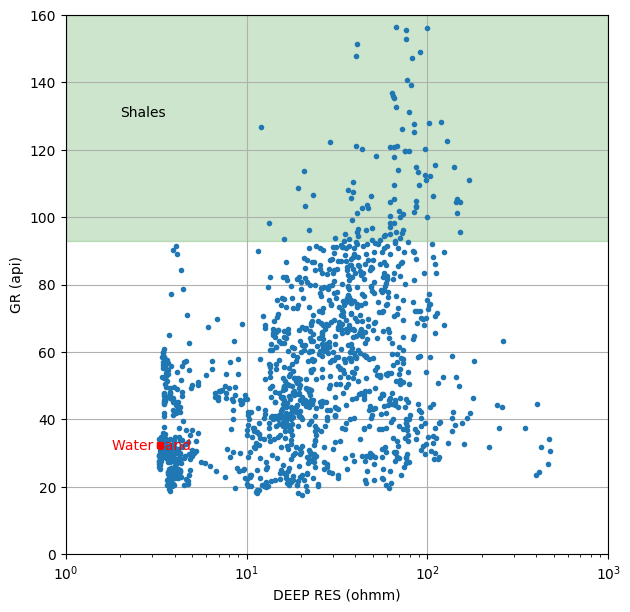

In [75]:
# Selection of a water bearing interval to compute the water resistivity

fix = 4900    # Depth of the estimation
print('ro =', rdeep[depth == fix])
print('phi =', log.comp_ephi[depth == fix])
print('temp =', log.temp[depth == fix])
print('600 is the index at depth of 4900 feet (fix) \n')

plt.figure(num=9, figsize=(7, 7))

plt.semilogx(rdeep, gr, '.')
plt.semilogx(rdeep[depth == fix], gr[depth == fix], 'rs', markersize=5)
plt.text(1.8, 31, 'Water sand', color='red')
plt.axhspan(93, 160, color='green', alpha=0.2)
plt.text(2, 130, 'Shales')
plt.xlim(1, 1000)
plt.ylim(0, 160)
plt.xlabel('DEEP RES (ohmm)')
plt.ylabel('GR (api)')
plt.grid(True)
plt.show()

In [76]:
# Rw estimation

ro_fix = 3.32    # Resistivity at the fix depth
phi_fix = 0.15    # Porosity at the fix depth
temp_fix = 98.73    # Temperature at the fix depth

# Archie's equation constants

a = 1
m = 2
n = 2

rw_fix = ro_fix*(phi_fix**m)    # Archie equation in water bearing sands

log['rw'] = rw_fix*(temp_fix + 21.5)*(1/(log.temp + 21.5))    # Rw along the well for temperature in ºC

# rw = rw_fix*(temp_fix + 6.77)*(1/(temp + 6.77))    # Rw along the well for temperature in ºF

In [77]:
# Water saturation by the Archie's equation in oil bearing sands

log['sw'] = ((log.rw/rdeep)*(a/(log.comp_ephi**m)))**(1/n)
log.sw = np.maximum(np.minimum(log.sw, 1), 0.0001)

In [78]:
# Before the next part let's define other aliases

vsh = log.vsh
comp_phi = log.comp_phi
comp_ephi = log.comp_ephi
badhole = log.badhole
sw = log.sw

<a  id="sum"></a>

<h2>3.2 Summation and report </h2>

The summation is a classification process in wich you can have a idea of the resources available in the well. This process can be esquematized in the following figure:

<img src="NB_images\summary.png" style="width:500px">

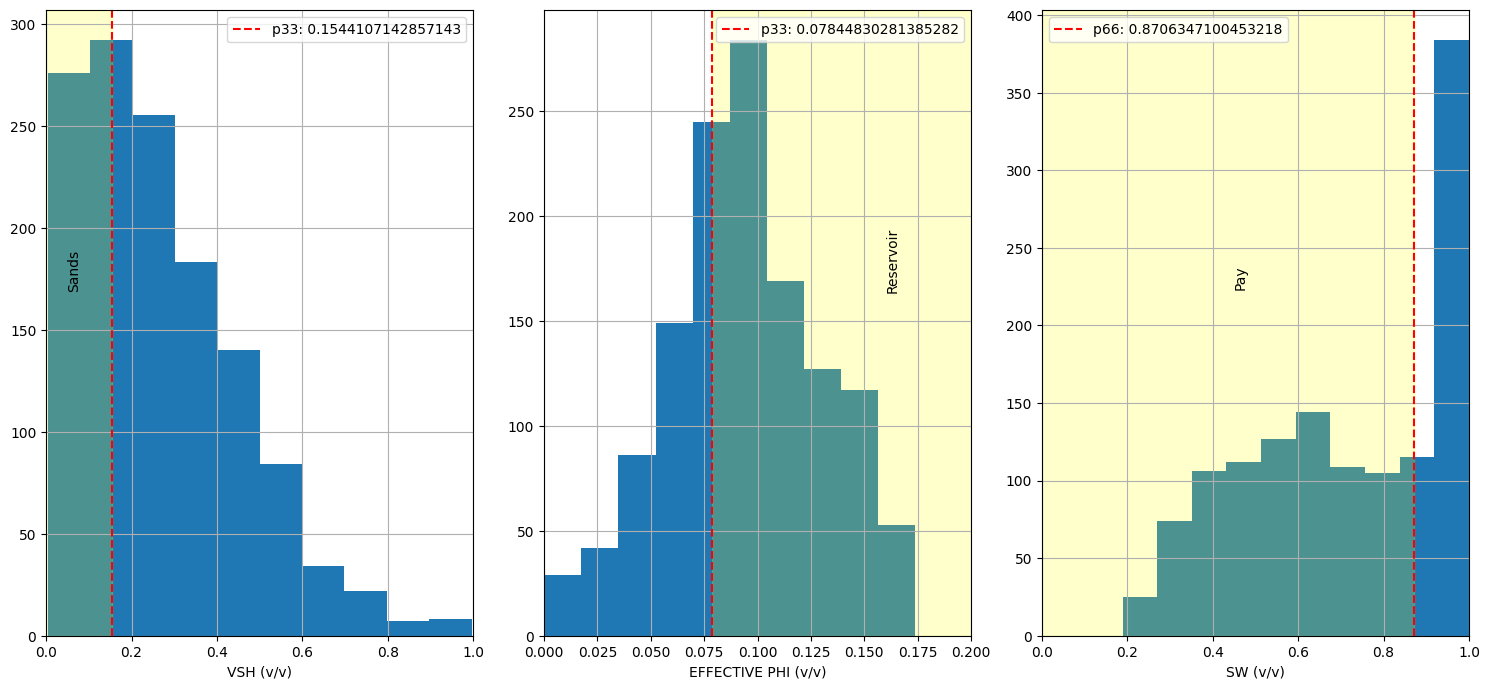

In [79]:
# Cutoffs, they change from zone to zone. If you don´t have then use the lower third of the curve

# %matplotlib inline

plt.figure(num=10, figsize=(15, 7))

plt.subplot(1,3,1)
plt.hist(vsh)
plt.axvline(x=np.percentile(vsh, 33), ls="--", color='red', label='p33: '+str(np.percentile(vsh, 33)))
plt.axvspan(0, np.percentile(vsh, 33), color='yellow', alpha=0.2)
plt.text(0.05, 170, 'Sands', rotation=90)
plt.legend()
plt.xlim(0, 1)
plt.xlabel('VSH (v/v)')
plt.grid(True)

plt.subplot(1,3,2)
plt.hist(comp_ephi)
plt.axvline(x=np.percentile(comp_ephi, 33), ls="--", color='red', label='p33: '+str(np.percentile(comp_ephi, 33)))
plt.axvspan(np.percentile(comp_ephi, 33), 2, color='yellow', alpha=0.2)
plt.text(0.160, 165, 'Reservoir', rotation=90)
plt.legend()
plt.xlim(0, 0.2)
plt.xlabel('EFFECTIVE PHI (v/v)')
plt.grid(True)

plt.subplot(1,3,3)
plt.hist(sw)
plt.axvline(x=np.percentile(sw, 66), ls="--", color='red', label='p66: '+str(np.percentile(sw, 66)))
plt.axvspan(0, np.percentile(sw, 66), color='yellow', alpha=0.2)
plt.text(0.45, 225, 'Pay', rotation=90)
plt.legend()
plt.xlim(0, 1)
plt.xlabel('SW (v/v)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [80]:
# Simple_stat to find the lower third of the curve

log_udf.basic_stat(vsh)

samples     = 1301
range       = 0.9926899999999999
min         = 0.003352142857142861
p33         = 0.1544107142857143
mean        = 0.26772911386845283
p66         = 0.3185735714285714
max         = 0.9960421428571428
std         = 0.18501610381074934
mean + 3std = 0.8227774253007007


In [81]:
# Simple_stat to find the lower third of the curve

log_udf.basic_stat(comp_ephi)

samples     = 1301
range       = 0.17378995874458875
min         = 0.0001
p33         = 0.07844830281385282
mean        = 0.09384624996976519
p66         = 0.106350583326226
max         = 0.17388995874458874
std         = 0.035784702405000486
mean + 3std = 0.20120035718476664


In [82]:
# Simple_stat to find the lower third of the curve

log_udf.basic_stat(sw)

samples     = 1301
range       = 0.8111562448523711
min         = 0.18884375514762886
p33         = 0.5842415251141961
mean        = 0.7126452944279063
p66         = 0.8706347100453218
max         = 1.0
std         = 0.23647996553311323
mean + 3std = 1.422085191027246


In [83]:
# Summation, counting sand, reservoir, and pay

# Cutoffs change from zone to zone. If you don´t have then use the lower third of the curve

vsh_ct = 0.15
phi_ct = 0.08
sw_ct = 0.87

log["sand"] = np.where((vsh < vsh_ct), 1, 0)
log["res"] = np.where(((log.sand == 1) & (comp_ephi > phi_ct )), 1, 0)
log["pay"] = np.where(((log.res  == 1) & (sw < sw_ct  )), 1, 0)

# Summe of the flag

total_sand = step*log.sand.sum()
total_res = step*log.res.sum()
total_pay = step*log.pay.sum()

In [84]:
# The previous done with loop and arrays (9 vs. 22 line of code)

# vsh_ct = 0.15
# phi_ct = 0.08
# sw_ct = 0.87

# sand = np.zeros(samples)    # Sand flag
# res = np.zeros(samples)    # Reservoir flag
# pay = np.zeros(samples)    # Pay or reservoir with oil flag

# for i in range(0, samples):

#     if vsh[i] < vsh_ct:
#         sand[i] = 1
#     else:
#         sand[i] = 0

#     if sand[i] == 1 and comp_eff_phi[i] > phi_ct:
#         res[i] = 1
#     else:
#         res[i] = 0

#     if res[i] == 1 and sw[i] < sw_ct:
#         pay[i] = 1
#     else:
#         pay[i] = 0

# # Summe of the flag

# total_sand = step*sum(sand)
# total_res = step*sum(res)
# total_pay = step*sum(pay)

In [85]:
# Executive summary

print('Cutoffs:')
print("vsh  <  ", vsh_ct)
print("phi  >  ", phi_ct)
print("sw  <  ", sw_ct, " \n")

print('Intervals:')

print('Total:', interval)
print('Sand:', total_sand)
print('Res:', total_res)
print('Sand_ntg:', total_sand/interval)
print('Pay:', total_pay)

Cutoffs:
vsh  <   0.15
phi  >   0.08
sw  <   0.87  

Intervals:
Total: 650.0
Sand: 209.0
Res: 187.0
Sand_ntg: 0.32153846153846155
Pay: 116.0


In [86]:
# Final report of parameters and results

file = open("Output/report.txt", "w")

file.writelines("REPORT\n")
file.writelines(" \n")
file.writelines("RANGE\n")
file.writelines("\n")
file.writelines("           top_interval:   "+str(top)+" \n")
file.writelines("          base_interval:   "+str(base)+" \n")
file.writelines("               interval:   "+str(interval)+" \n")
file.writelines("                   step:   "+str(step)+" \n")
file.writelines("                samples:   "+str(samples)+" \n")
file.writelines("\n")
file.writelines("SHALE VOLUME\n")
file.writelines("\n")
file.writelines("                  gr_cl:   "+str(gr_cl)+" \n")
file.writelines("                  gr_sh:   "+str(gr_sh)+" \n")
file.writelines("\n")
file.writelines("WATER RESISTIVITY\n")
file.writelines("\n")
file.writelines("           estimation @:   "+str(fix)+" \n")
file.writelines("                     ro:   "+str(ro_fix)+" \n")
file.writelines("                    phi:   "+str(phi_fix)+" \n")
file.writelines("                     rw:   "+str(rw_fix)+" \n")
file.writelines("                   temp:   "+str(temp_fix)+" \n")
file.writelines("\n")
file.writelines("ARCHIE SW\n")
file.writelines("\n")
file.writelines("                      a:   "+str(a)+" \n")
file.writelines("                      m:   "+str(m)+" \n")
file.writelines("                      n:   "+str(n)+" \n")
file.writelines("\n")
file.writelines("SUMMATION CUTOFF\n")
file.writelines("\n")
file.writelines("                     vsh  <  "+str(vsh_ct)+" \n")
file.writelines("                     phi  >  "+str(phi_ct)+" \n")
file.writelines("                      sw  <  "+str(sw_ct)+" \n")
file.writelines("\n")
file.writelines("SUMMATION RESULTS\n")
file.writelines("\n")
file.writelines("                   sand:  "+str(total_sand)+" \n")
file.writelines("                    res:  "+str(total_res)+" \n")
file.writelines("               sand_ntg:  "+str(total_sand/interval)+" \n")
file.writelines("                    pay:  "+str(total_pay)+" \n")

file.close()

In [87]:
# Exporting the output or calculated logs

output = log[['depth', 'badhole', 'vsh', 'comp_ephi', 'sw', 'sand', 'res', 'pay']]
output.to_excel('Output/output_logs.xlsx')
output.to_csv('Output/output_logs.csv')

<a  id="outcross"></a>

<h2>3.3 Output logs cross plots </h2>

As well as the input log, you can do cross plot with the output log or with a mix of them:

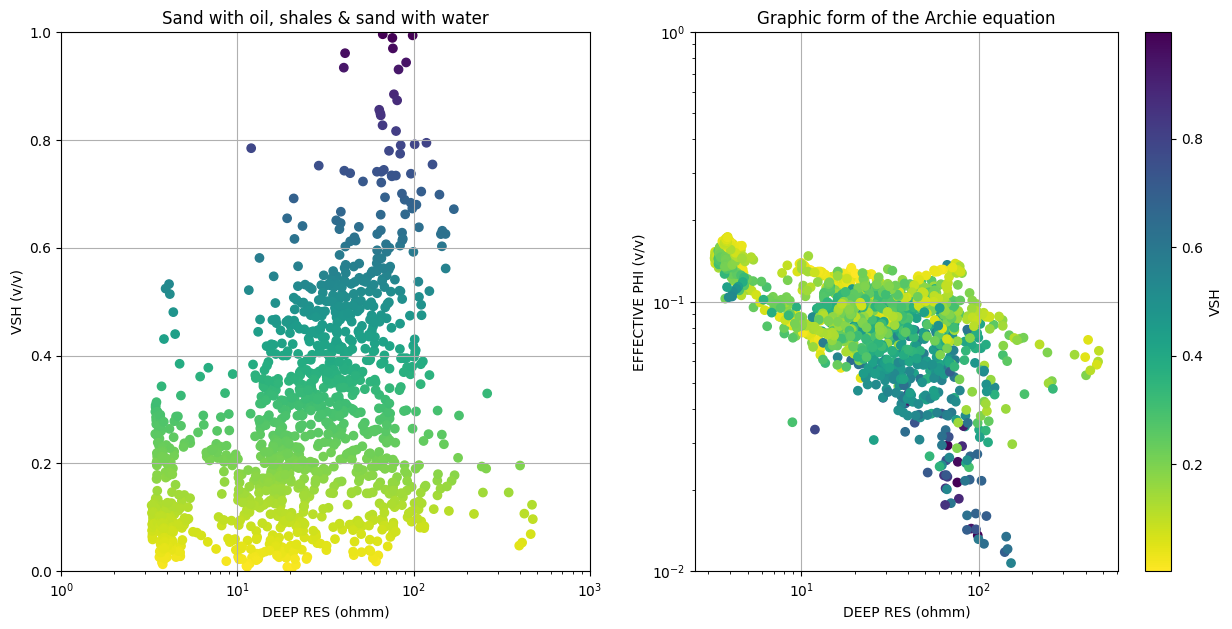

In [88]:
# Two input-output logs cross plot

# %matplotlib inline

plt.figure(num=11, figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.scatter(rdeep, vsh, c=vsh, cmap='viridis_r')
plt.xscale("log") 
plt.axis([1, 1000, 0, 1])
plt.xlabel('DEEP RES (ohmm)')
plt.ylabel('VSH (v/v)')
plt.title('Sand with oil, shales & sand with water')
plt.grid(True)

# Scatter plot, logx logy plot with the color of the point controlled by z (vsh) 

plt.subplot(1, 2, 2)
plt.scatter(rdeep, comp_ephi, c=vsh, cmap='viridis_r')
#plt.xlim(1, 1000)
plt.ylim(0.01, 1)
plt.yscale("log")
plt.xscale("log") 
plt.xlabel('DEEP RES (ohmm)')
plt.ylabel('EFFECTIVE PHI (v/v)')
plt.title('Graphic form of the Archie equation')
plt.grid(True)

# Color scale bar

cb = plt.colorbar()
cb.set_label('VSH')

plt.show()

<a  id="outdis"></a>

<h2>3.4 Output logs display </h2>

As well as the input log, the output can be displayed in a multiplot:

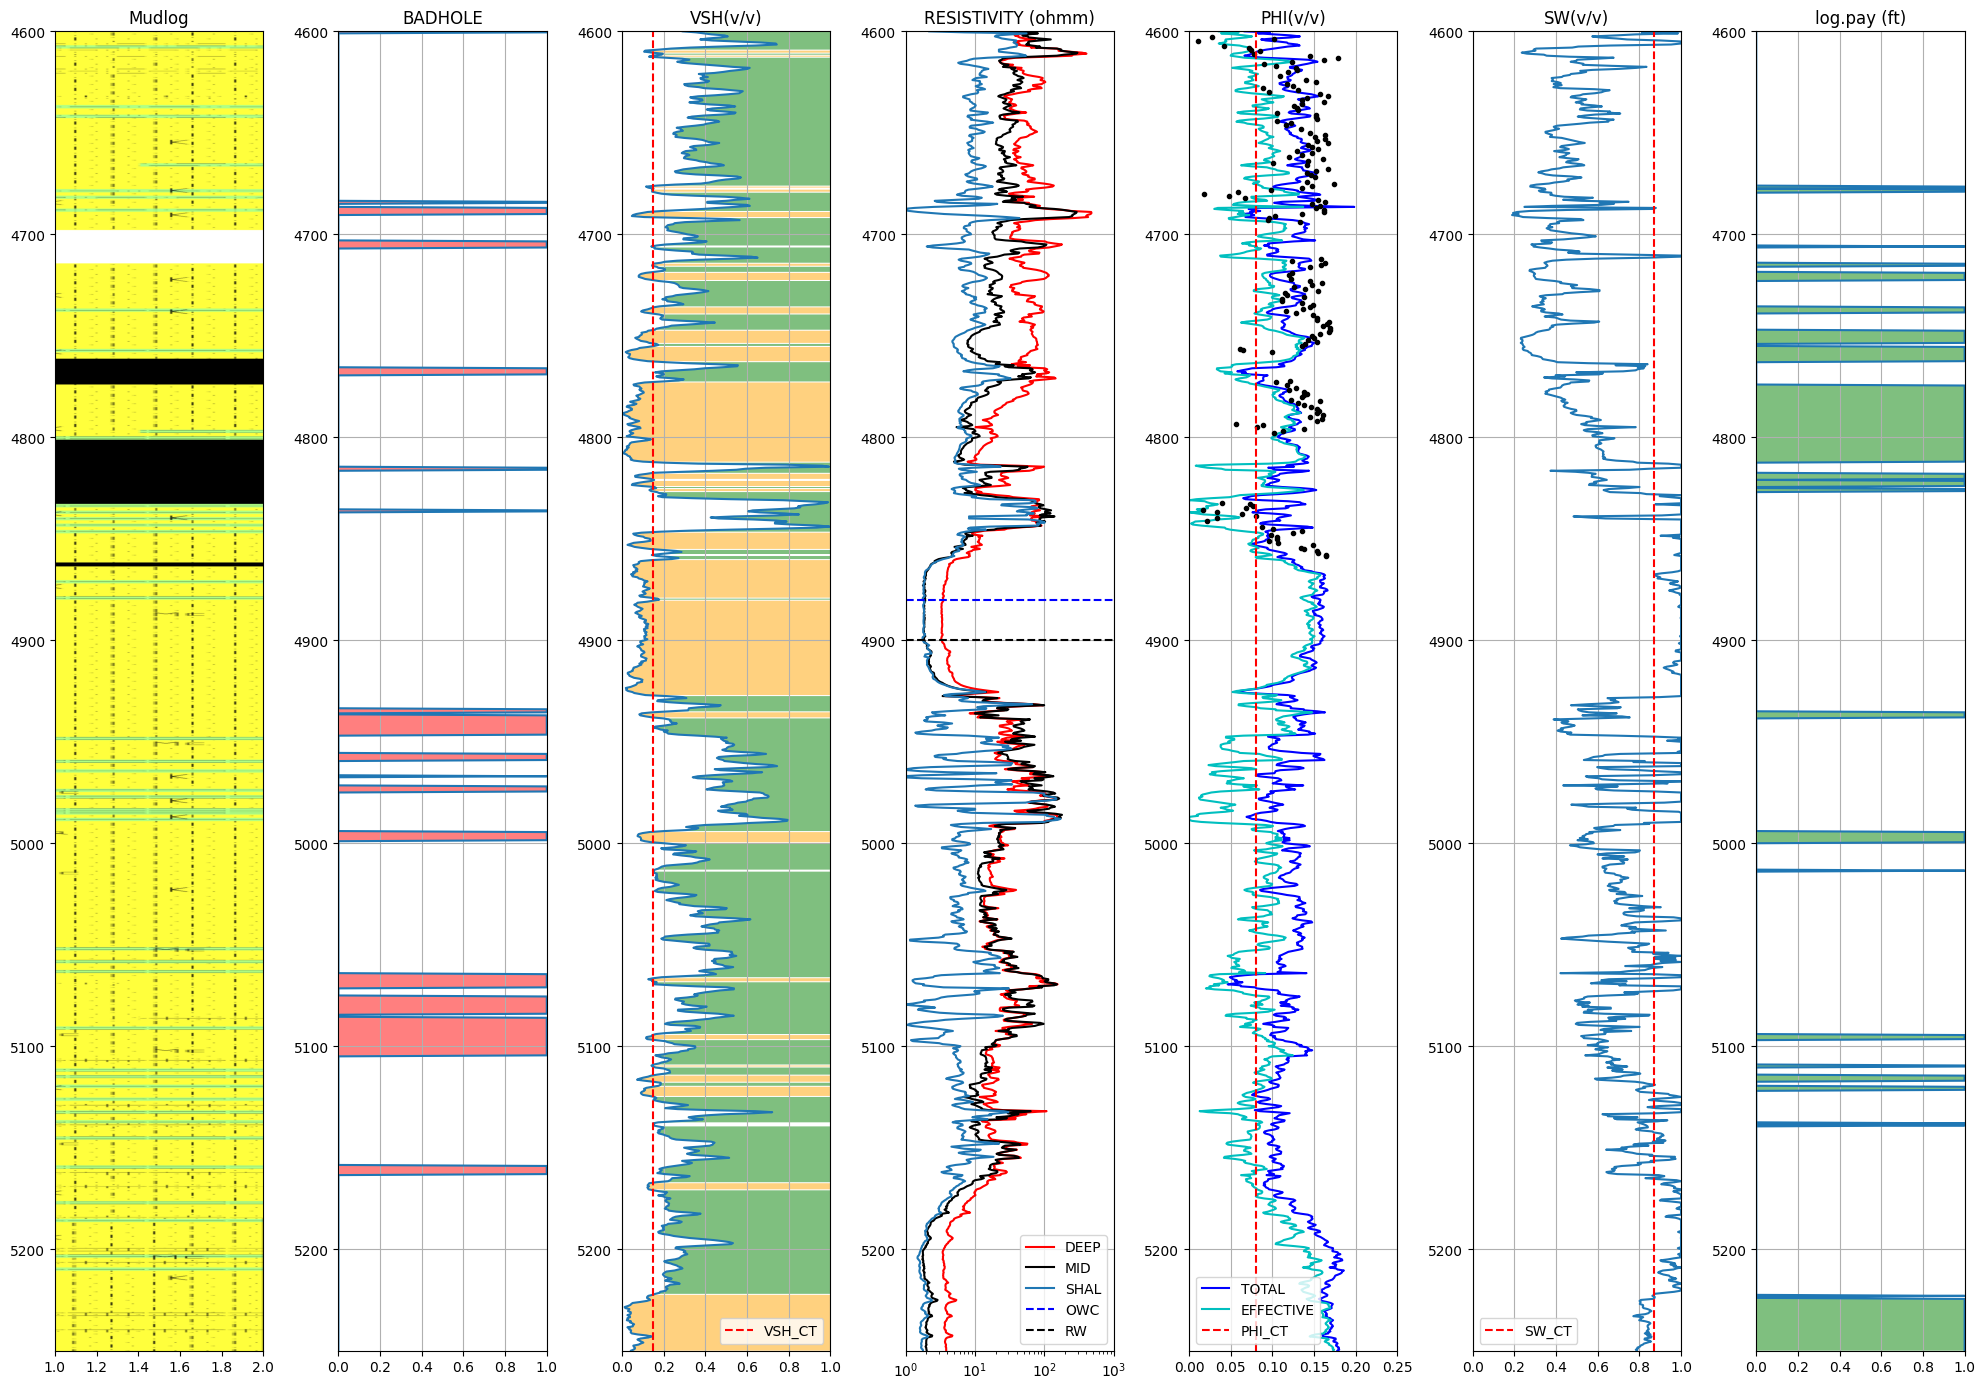

In [89]:
# Multiplo display of the output log

plt.figure(num=12, figsize=(20, 14))

# Simple display of the output logs

# Track 1
plt.subplot(1, 7, 1)
plt.imshow(mudlog, aspect='auto', extent=(1, 2, base, top))
plt.title('Mudlog')

# Track 2
plt.subplot(1,7,2)
plt.plot(badhole, depth)
plt.fill_betweenx(depth, badhole, where=badhole >= 0, facecolor='red',alpha=0.5)
plt.axis([0, 1, base, top])
plt.title ('BADHOLE')
plt.grid(True)

# Track 3
plt.subplot(1,7,3)
plt.plot(vsh, depth)
plt.axis([0, 1, base, top])
plt.title ('VSH(v/v)')
plt.grid(True)
plt.axvline(x=vsh_ct, ls="--", color='red', label='VSH_CT')
plt.fill_betweenx(depth, vsh, 1, vsh >= vsh_ct, facecolor='green',alpha=0.5)
plt.fill_betweenx(depth, vsh, 1, vsh < vsh_ct, facecolor='orange',alpha=0.5)

plt.legend()

# Track 4
plt.subplot(1,7,4)
plt.semilogx(rdeep, depth, 'r', label="DEEP")
plt.semilogx(rmed, depth, 'k', label="MID")
plt.semilogx(rshal, depth, label="SHAL")
plt.axis([1, 1000, base, top])
plt.axhline(y= 4880, ls="--", color='blue', label='OWC')
plt.axhline(y= 4900, ls="--", color='black', label='RW')
plt.title('RESISTIVITY (ohmm)')
plt.legend()
plt.grid(True)

# Track 5
plt.subplot(1,7,5)
plt.plot(comp_phi,depth,'b', label='TOTAL')
plt.plot(comp_ephi,depth,'c', label='EFFECTIVE')
plt.plot(core_phi, depth, '.', color='black')
plt.axis([0, 0.25, base, top])
plt.axvline(x=phi_ct, ls="--", color='red', label='PHI_CT')
plt.title ('PHI(v/v)')
plt.legend()
plt.grid(True)

# Track 6
plt.subplot(1,7,6)
plt.plot(sw,depth)
plt.axis([0,1, base, top])
plt.axvline(x=sw_ct, ls="--", color='red', label='SW_CT')
plt.title ('SW(v/v)')
plt.legend()
plt.grid(True)

# Track 7
plt.subplot(1,7,7)
plt.plot(log.pay,depth)
plt.fill_betweenx(depth, log.pay, where=log.pay >= 0, facecolor='green',alpha=0.5)
plt.axis([0, 1, base, top])
plt.title('log.pay (ft)')
plt.grid(True)

plt.tight_layout()
plt.show()

[Return to Table of Content](#toc)

<a  id="simple"></a>

<h1>4 Simple estimations of efacie and K </h1>

The estimation of efacies and permeabilities present along the well is an additional step in the log interpretation, essential for assessing the production potential of the well. This task can be done in many ways according to the necessities and data availability. Here we will see just simple techniques, based more on intuition than on physical laws. 

Before applying linear regressions (the simplest ML method that we all know) on all the core pairs (phi-k), it is mandatory to separate the core pairs into categories (based on the core  properties or based on the log properties at the core positions) and generate regressions for each one. As the core samples are discontinuous, the different equations from the core can be used over the logs to propagate the permeability along the well. The procedure will be this:

* Take the vsh (or any other log related to flow quality) and divide it into three portions based on the p33 and p66 percentiles, assign a label to each portion (1, 2, 3) which are going to be efacies
* Assing the efacies from the logs to the core pairs based on their positions in the logs 
* Isolate the core pairs for each efacie and apply a regression on each group
* Use the regression for each efacie to propagate the K along the well (equivalent to a composite K)

In [187]:
# Plots that show the challenge of splitting the data

plt.figure(num=13, figsize=(20, 7))

# Plots based on the core data

plt.subplot(1,4,1)
plt.scatter(core_phi, core_k, c=vsh, cmap='viridis_r')
plt.axis([0, 0.25, 0.001, 1000])
plt.xlabel('CORE PHI (v/v)')
plt.ylabel('K (mD)')
plt.grid(True)

plt.subplot(1,4,2)
plt.scatter(core_phi, core_k, c=vsh, cmap='viridis_r')
plt.yscale("log")
plt.axis([0, 0.25, 0.001, 1000])
plt.xlabel('CORE PHI (v/v)')
plt.ylabel('K (mD)')
plt.grid(True)

# Plots based on the output data

plt.subplot(1,4,3)
plt.scatter(vsh, comp_phi, c=vsh, cmap='viridis_r')
# plt.yscale("log")
plt.axis([1, 0, 0, 0.2])
plt.xlabel('VSH (v/v)')
plt.ylabel('COMP PHI (v/v)')
plt.grid(True)

plt.subplot(1,4,4)
plt.scatter(vsh, comp_ephi, c=vsh, cmap='viridis_r')
# plt.yscale("log")
plt.axis([1, 0, 0, 0.2])
plt.xlabel('VSH (v/v)')
plt.ylabel('COMP EFFECTIVE PHI (v/v)')
plt.grid(True)

cb = plt.colorbar()
cb.set_label('VSH')

plt.tight_layout()
plt.show()

# The spread of the data in this last plot shows a promising relation between vsh and the effective porosity

<a  id="type"></a>

## 4.1 Simple rock typing

Let's make a simple categories or rock types (efacie) with the percentile of the vsh:

In [188]:
# A simple efacie from two logs that give us quality, the volume of sand, and the composite effective porosity

log['qual'] = (1 - vsh)*comp_ephi*100    # Higher the qual the better

print(log_udf.basic_stat(log.qual), '\n')
log.qual

In [189]:
plt.close('6')

plt.figure(num=14, figsize=(7, 4))
log_udf.histo_par(log.qual, 'QUAL')

In [190]:
# Estimating the efacie by conditions on the qual log

log["efacie"] = np.where((log.qual > np.percentile(log.qual,66)), 1, 2)
log.efacie = np.where((log.qual < np.percentile(log.qual,33)), 3, log.efacie)

# Unique values in the log of efacie

print('Values in the efacie log:', log.efacie.unique(), '\n')
print('NaNs in the efacie log:', log.efacie.isna().sum(), '\n')
log.efacie

In [191]:
# Cluster of the efacie for plotting, is it just a repetition

cluster_efacie = np.repeat(np.expand_dims(log.efacie, 1), 3, 1)
print(type(cluster_efacie))
cluster_efacie

In [192]:
# Masks the core pairs with the categories

log['phi1'], log['k1'] = log.core_phi[log.efacie == 1], log.core_k[log.efacie == 1]
log['phi2'], log['k2'] = log.core_phi[log.efacie == 2], log.core_k[log.efacie == 2]
log['phi3'], log['k3'] = log.core_phi[log.efacie == 3], log.core_k[log.efacie == 3]

print(log.phi1.count() + log.phi2.count() + log.phi3.count())

#  Here we can see that k1>k2>k3

log[['phi1', 'phi2', 'phi3', 'k1', 'k2', 'k3']].describe()

In [193]:
# Info on NaNs and type of variables

# Number of values in k1, k2, and k3 is 182

log.info()

In [194]:
# New alias

phi1 = log.phi1
phi2 = log.phi2
phi3 = log.phi3
k1 = log.k1
k2 = log.k2
k3 = log.k3

In [195]:
# Grouping parameters of the efacies by list comprehension

phis = [phi1, phi2, phi3]
ks = [k1, k2, k3]

par_phis = list(x.max() for x in phis)
par_ks = list(x.max() for x in ks)

print(par_phis)
par_ks

In [196]:
# PLot of the properties

plt.figure(num=14, figsize=(6, 6))

plt.plot(par_phis, par_ks, marker = 'o', ms = 10, mfc = 'r')
plt.grid(True)
plt.xlabel('Max phi of efacies')
plt.ylabel('Max k of efacies')
plt.title('Efacie vs. property')

for i in range(0, 3):
    plt.text(par_phis[i] + 0.0003, par_ks[i], str(i+1 )) 

plt.show()

<a  id="re"></a>

## 4.2 Regression and residual

Functions `np.polyfit` and `np.poly1d` are powerful tools to do **polynomial regressions** of different degrees on experiment data. In our case, we are going to work straight line so the variable y (permeability) has to be linearized by log(y). Other important variable linearizations are shown below:


Relationship |  Example   |     General Eqn.     |  Altered Var.  |        Linearized Eqn.  
-------------|------------|----------------------|----------------|------------------------------------------
Linear       | x          | y =     B * x    + C | -              |        y =   C    + B * x
Logarithmic  | log(x)     | y = A * log(B*x) + C | log(x)         |        y =   C    + A * (log(B) + log(x))
Exponential  | 2^x, e^x | y = A * exp(B*x) + C | log(y)         | log(y-C) = log(A) + B * x
Power        | x^2       | y =     B * x^N + C | log(x), log(y) | log(y-C) = log(B) + N * log(x)

In [197]:
# Function regression and residual (e)

def reg_res(x, y, degree):
    
    '''This function calculates a polynomial that fit to the given data and returns the equation, 
    residual, MSE, and R2.'''
    
    x = x[~x.isna()]
    y = y[~y.isna()]
    
    poly_coeff = np.polyfit(x, y, degree)
    
    newy = np.poly1d(poly_coeff)
    
    e = y - np.exp(newy(x))
    
    mse = mean_squared_error(y, np.exp(newy(x)))
    
    r2 = r2_score(y, newy(x))
    
    return newy, e, mse, r2

In [198]:
# All pairs regression and residual

newy0, e0, mse0, r20= reg_res(core_phi, np.log10(core_k), 1)
print('Equation: ', newy0)
print('Mean residual:', np.mean(e0), '\n')
print('MSE:' , mse0)
print('R2:' , r20)

In [199]:
# Category 1 regression and residual

newy1, e1, mse1, r21= reg_res(phi1, np.log10(k1), 1)
print('Equation: ', newy1)
print('Mean residual:', np.mean(e1), '\n')
print('MSE:' , mse1)
print('R2:' , r21)

In [200]:
# Category 2 regression and residual

newy2, e2, mse2, r22 = reg_res(phi2, np.log10(k2), 1)
print('Equation: ', newy2, '\n')
print('Mean residual:', np.mean(e2))
print('MSE:' , mse2)
print('R2:' , r22)

In [201]:
# Category 3 regression and residual

newy3, e3, mse3, r23= reg_res(phi3, np.log10(k3), 1)
print('Equation: ', newy3, '\n')
print('Mean residual:', np.mean(e3))
print('MSE:' , mse3)
print('R2:' , r23)

In [202]:
# Isolated categories with corresponding regression and residual plots

# %matplotlib inline

x = np.arange(0.005, 0.25, 0.01)

plt.figure(num=14, figsize=(20, 15))

# All pairs

plt.subplot(4, 2, 1)
plt.scatter(core_phi, core_k, c=log.efacie, cmap='viridis_r')
plt.plot(x, np.exp(newy0(x)), color='black', label='All efacies regression')
plt.text(0.01, 2, 'log10(y) = '+str(newy0)[2:])
plt.yscale("log")
plt.axis([0, 0.25, 0.001, 1000])
plt.ylabel('K (mD)')
plt.grid(True)
plt.legend()

# All pairs residual plot

plt.subplot(4, 2, 2)
plt.scatter(core_phi[~core_phi.isna()], e0, c=log.efacie[~core_phi.isna()], cmap='viridis_r')
plt.axhline(y=np.mean(e0), color='black', label="Mean of residual")
plt.ylabel('Residual')
plt.grid(True)
plt.legend()

# Efacie1

color_efacie1 = (253/256, 231/256, 37/256)
color_efacie2 = (35/256, 144/256, 137/256)
color_efacie3 = (68/256, 1/256, 84/256)

plt.subplot(4, 2, 3)
plt.scatter(phi1, k1, color=[color_efacie1], label='Efacie1')
plt.plot(x, np.exp(newy1(x)), color='black', label='Efacie1 regression')
plt.yscale("log")
plt.axis([0, 0.25, 0.001, 1000])
plt.ylabel('K (mD)')
plt.text(0.01, 2, 'log10(y) = '+str(newy1)[2:])
plt.grid(True)
plt.legend()

# Efacie1 residual plot

plt.subplot(4, 2, 4)
plt.scatter(phi1[~phi1.isna()], e1, color=[color_efacie1], label='Efacie1 residual')
plt.axhline(y=np.mean(e1), color='black', label="Mean of residual")
plt.ylabel('Residual')
plt.grid(True)
plt.legend()

# Efacie2

plt.subplot(4, 2, 5)
plt.scatter(phi2, k2, color=[color_efacie2], label='Efacie2')
plt.plot(x, np.exp(newy2(x)), color='black', label='Regression')
plt.yscale("log")
plt.axis([0, 0.25, 0.001, 1000])
plt.ylabel('K (mD)')
plt.text(0.01, 2, 'log10(y) = '+str(newy2)[2:])
plt.grid(True)
plt.legend()

plt.subplot(4, 2, 6)
plt.scatter(phi2[~phi2.isna()], e2, color=[color_efacie2], label='Efacie2 residual')
plt.axhline(y=np.mean(e2), color='black', label="Mean of residual")
plt.ylabel('Residual')
plt.grid(True)
plt.legend()

plt.subplot(4, 2, 7)
plt.scatter(phi3, k3, color=[color_efacie3], label='Efacie3')
plt.plot(x, np.exp(newy3(x)), color='black', label='Regression')
plt.yscale("log")
plt.axis([0, 0.25, 0.001, 1000])
plt.xlabel('CORE PHI (v/v)')
plt.ylabel('K (mD)')
plt.text(0.01, 2, 'log10(y) = '+str(newy3)[2:])
plt.grid(True)
plt.legend()

plt.subplot(4, 2, 8)
plt.scatter(phi3[~phi3.isna()], e3, color=[color_efacie3], label='Efacie3 residual')
plt.axhline(y=np.mean(e3), color='black', label="Mean of residual")
plt.xlabel('CORE PHI (v/v)')
plt.ylabel('Residual')
plt.grid(True)
plt.legend(loc='upper left')

plt.show()

**Residuals** provide an excellent way to assess the quality of the regression:

 + The sum and mean of the residuals have to be close to zero
 + Residuals have to be randomly distributed around zero
 + Residuals do not have to show patterns
 + Patterns such as those below have different implications:
 
 <img src="https://condor.depaul.edu/sjost/it223/documents/resid-plots.gif" style="float:center" width="500px" />

Image from: https://condor.depaul.edu/sjost/it223/documents/regress.htm

Another reference: https://www.qualtrics.com/support/stats-iq/analyses/regression-guides/interpreting-residual-plots-improve-regression/#x-unbalanced-header

What efacie do you think has the best phi-k regression?

<a  id="propa"></a>

## 4.3 K propagation along the well

Let's propagate the K along the well using the regression equations of each efacie or rock type or category:

In [203]:
print(newy1)
type(newy1)

In [204]:
# Composite K along the well

log["comp_k"] = np.where((log.efacie == 1), 10**newy1(comp_ephi), 10**newy2(comp_ephi))
log.comp_k = np.where((log.efacie == 3), 10**newy3(comp_ephi), log.comp_k)

print(log.comp_k.describe(), '\n')

log.comp_k

In [205]:
# Correlation between K

log[['core_k', 'comp_k']].corr()

The technique to plot the facies, using `imshow()`, was taken and modified from: 

https://github.com/seg/tutorials-2016/blob/master/1610_Facies_classification/Facies%20Classification%20-%20SVM.ipynb

In [206]:
# Multiplot display of the output log

plt.figure(num=15, figsize=(20, 11))

# Simple display of the output logs

# Track 1
plt.subplot(1, 9, 1)
plt.imshow(mudlog, aspect='auto', extent=(1, 2, base, top))
plt.title('Mudlog')

# Track 2
plt.subplot(1,9,2)
plt.plot(badhole,depth)
plt.fill_betweenx(depth, badhole, where=badhole >= 0, facecolor='red',alpha=0.3)
plt.axis([0, 1, base, top])
plt.title ('BADHOLE')
plt.grid(True)

# Track 3
plt.subplot(1,9,3)
plt.plot(vsh,depth)
plt.axis([0, 1, base, top])
plt.title ('VSH(v/v)')
plt.grid(True)
plt.fill_betweenx(depth, vsh, 1, vsh >= vsh_ct, facecolor='green',alpha=0.3)
plt.fill_betweenx(depth, vsh, 1, vsh < vsh_ct, facecolor='orange',alpha=0.3)
plt.axvline(x=vsh_ct, ls="--", color='red', label='VSH_CT')
plt.legend()

# Track 4
plt.subplot(1,9,4)
plt.semilogx(rdeep, depth, 'r', label="DEEP")
plt.semilogx(rmed, depth, 'k', label="MID")
plt.semilogx(rshal, depth, label="SHAL")
plt.axis([1, 1000, base, top])
plt.axhline(y= 4880, ls="--", color='blue', label='OWC')
plt.text(40, 4878, 'OWC')
plt.title('RESISTIVITY (ohmm)')
plt.legend()
plt.grid(True)

# Track 5
plt.subplot(195)
plt.plot(comp_phi,depth,'b', label='TOTAL')
plt.plot(comp_ephi,depth,'c', label='EFFECTIVE')
plt.plot(core_phi, depth, '.', color='black', label='CORE')
plt.axis([0, 0.25, base, top])
plt.axvline(x=phi_ct, ls="--", color='red', label='PHI_CT')
plt.title ('PHI(v/v)')
plt.legend()
plt.grid(True)

# Track 6
plt.subplot(196)
plt.plot(sw,depth)
plt.axis([0, 1, base, top])
plt.axvline(x=sw_ct, ls="--", color='red', label='SW_CT')
plt.title ('SW(v/v)')
plt.legend()
plt.grid(True)

# Track 7
plt.subplot(197)
plt.plot(log.pay,depth)
plt.fill_betweenx(depth, log.pay, where=log.pay >= 0, facecolor='green',alpha=0.3)
plt.axis([0, 1, base, top])
plt.title('PAY (ft)')
plt.grid(True)


# Track 8
plt.subplot(198)
plt.plot(log.efacie,depth, '.', markersize=0)
plt.imshow(cluster_efacie, interpolation='none', aspect='auto',cmap='viridis_r', extent=(1, 3, base, top))
# plt.axis([1, 3, base, top])
plt.title('EFACIE')
plt.grid(True)

# Track 9
plt.subplot(199)
plt.semilogx(log.comp_k,depth)
plt.semilogx(core_k, depth, '.', color='black', label='CORE')
#plt.fill_betweenx(depth, pay, where=pay >= 0, facecolor='green',alpha=0.3)
plt.axis([0.01, 100000, base, top])
plt.title('K (mD)')
plt.grid(True)

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">
<font size="6">&#128692;</font><b> Exercise:</b>
</div>